<a href="https://www.kaggle.com/code/skanderadamafi/e-commerce-customer-segmentation?scriptVersionId=293731169" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.simplefilter(action='ignore')
sns.set(rc={'figure.figsize': [10, 10]}, font_scale=1.3)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE

# **Load dataset**

In [2]:
df = pd.read_csv('/kaggle/input/online-retail/Online_Retail.csv', encoding='ISO-8859-1')

# **Data exploration**

In [3]:
df.shape

(541909, 8)

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# **Data cleaning**



*   Fix numerical data



In [6]:
for i in df['Quantity'].unique():
    print(i)

6
8
2
32
3
4
24
12
48
18
20
36
80
64
10
120
96
23
5
1
-1
50
40
100
192
432
144
288
-12
-24
16
9
128
25
30
28
7
56
72
200
600
480
-6
14
-2
11
33
13
-4
-5
-7
-3
70
252
60
216
384
-10
27
15
22
19
17
21
34
47
108
52
-9360
-38
75
270
42
240
90
320
1824
204
69
-36
-192
-144
160
2880
1400
39
-48
-50
26
1440
31
82
78
97
98
35
57
-20
110
-22
-30
-70
-130
-80
-120
-40
-25
-14
-15
-69
-140
-320
-8
720
156
324
38
37
49
95
-9
-11
29
41
-72
-35
-21
-43
-19
-18
-44
402
378
150
300
54
104
67
258
66
44
55
46
99
61
408
972
208
1008
1000
-77
1488
250
1394
400
-223
-150
-13
-33
-723
-177
79
84
-32
-100
-28
272
-145
-47
-96
113
45
106
68
267
115
65
1728
-60
-16
53
-240
76
460
71
43
213
58
576
2400
500
180
-300
-500
-23
752
960
1296
210
172
215
129
138
116
135
197
-106
-54
-17
-939
147
168
256
-201
-53
-29
-2600
-990
-290
-45
860
1010
1356
1284
186
114
360
1930
2000
3114
1300
670
111
211
59
-310
-61
-41
176
648
62
74215
-74215
-64
-84
89
-1400
73
-57
112
456
-59
-31
5568
2560
136
900
-600
-42
-94
-207
-52
1



*   Delete the numbers that starts with(-)




In [7]:
df['Quantity'] = df['Quantity'].astype(str)

In [8]:
def fix_quantity(x):

        if x[0]== "-":
            return float(x[1:])
        else:

            return float(x)

In [9]:
df["Quantity"] = df["Quantity"].apply(fix_quantity)



*   Check the result



In [10]:
for i in df['Quantity'].unique():
    print(i)

6.0
8.0
2.0
32.0
3.0
4.0
24.0
12.0
48.0
18.0
20.0
36.0
80.0
64.0
10.0
120.0
96.0
23.0
5.0
1.0
50.0
40.0
100.0
192.0
432.0
144.0
288.0
16.0
9.0
128.0
25.0
30.0
28.0
7.0
56.0
72.0
200.0
600.0
480.0
14.0
11.0
33.0
13.0
70.0
252.0
60.0
216.0
384.0
27.0
15.0
22.0
19.0
17.0
21.0
34.0
47.0
108.0
52.0
9360.0
38.0
75.0
270.0
42.0
240.0
90.0
320.0
1824.0
204.0
69.0
160.0
2880.0
1400.0
39.0
26.0
1440.0
31.0
82.0
78.0
97.0
98.0
35.0
57.0
110.0
130.0
140.0
720.0
156.0
324.0
37.0
49.0
95.0
29.0
41.0
43.0
44.0
402.0
378.0
150.0
300.0
54.0
104.0
67.0
258.0
66.0
55.0
46.0
99.0
61.0
408.0
972.0
208.0
1008.0
1000.0
77.0
1488.0
250.0
1394.0
400.0
223.0
723.0
177.0
79.0
84.0
272.0
145.0
113.0
45.0
106.0
68.0
267.0
115.0
65.0
1728.0
53.0
76.0
460.0
71.0
213.0
58.0
576.0
2400.0
500.0
180.0
752.0
960.0
1296.0
210.0
172.0
215.0
129.0
138.0
116.0
135.0
197.0
939.0
147.0
168.0
256.0
201.0
2600.0
990.0
290.0
860.0
1010.0
1356.0
1284.0
186.0
114.0
360.0
1930.0
2000.0
3114.0
1300.0
670.0
111.0
211.0
59.0
310.0
176.

In [11]:
for i in df['UnitPrice'].unique():
    print(i)

2.55
3.39
2.75
7.65
4.25
1.85
1.69
2.1
3.75
1.65
4.95
9.95
5.95
7.95
0.85
0.65
1.25
2.95
1.95
0.42
18.0
1.06
6.95
10.95
3.45
0.55
0.38
1.45
3.95
6.75
27.5
14.95
16.95
4.65
6.45
12.75
19.95
8.5
3.82
3.37
5.45
6.35
0.72
0.64
0.1
0.32
1.48
0.29
165.0
35.75
3.35
10.65
15.0
0.95
0.21
0.12
0.0
0.24
3.25
1.49
2.25
1.55
18.95
8.95
50.0
2.51
1.66
0.43
7.62
4.21
2.98
5.91
3.36
16.98
1.28
11.02
8.47
0.81
5.06
12.72
10.17
6.77
20.38
11.87
25.49
51.02
9.32
34.0
0.84
16.13
21.23
18.68
14.43
3.81
4.24
1.26
5.09
2.96
2.11
569.77
13.57
29.95
4.6
1.05
5.49
59.53
15.28
19.53
2.82
1.27
3.19
0.99
2.13
5.51
8.49
8.07
7.22
2.54
9.34
5.94
607.49
0.19
10.75
24.95
79.95
11.95
0.03
0.75
0.36
0.34
0.16
1.88
7.25
0.18
295.0
40.0
5.74
29.79
254.43
121.06
498.47
1.84
6.37
887.52
3.83
28.0
7.5
42.95
21.95
26.95
29.29
0.14
5.55
49.95
1.0
3.49
76.55
10.62
7.64
863.74
39.96
11.05
940.87
15.95
35.0
4.41
0.3
9.77
0.83
950.99
6.6
1.93
3.21
0.53
924.59
95.38
12.95
52.0
281.0
631.31
313.78
0.07
13541.33
1.7
836.14
229.74
448

=> For the UnitPrice column the data is clean and float



*   check for null values



In [12]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



*   Drop all the null values



In [13]:
df=df.dropna()



*   Recheck for null values



In [14]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [15]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,13.412279,3.460471,15287.690570
std,248.624170,69.315162,1713.600303
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


it is clear that there are :

*   outliers in both Quantity & UnitPrice
*   zero values in [ UnitPrice ] which doesn't make sense





*   Detect and handle outliers



<Axes: ylabel='Quantity'>

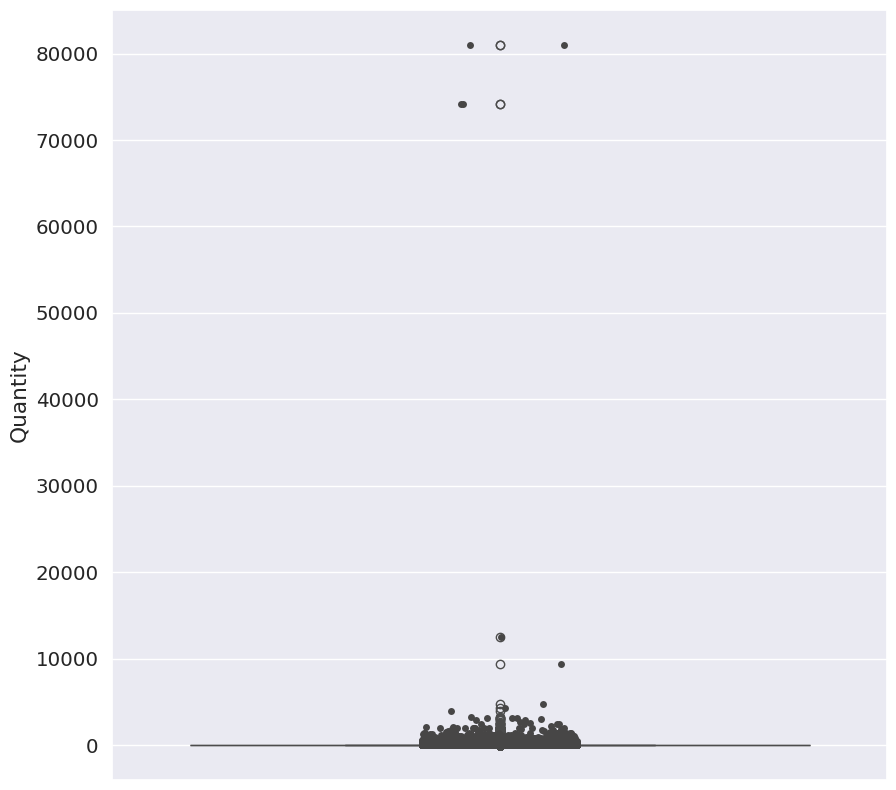

In [16]:
sns.boxplot( y='Quantity',data=df)
sns.stripplot(y='Quantity',data=df, color="#474646")



*   Drop outliers



<Axes: ylabel='Quantity'>

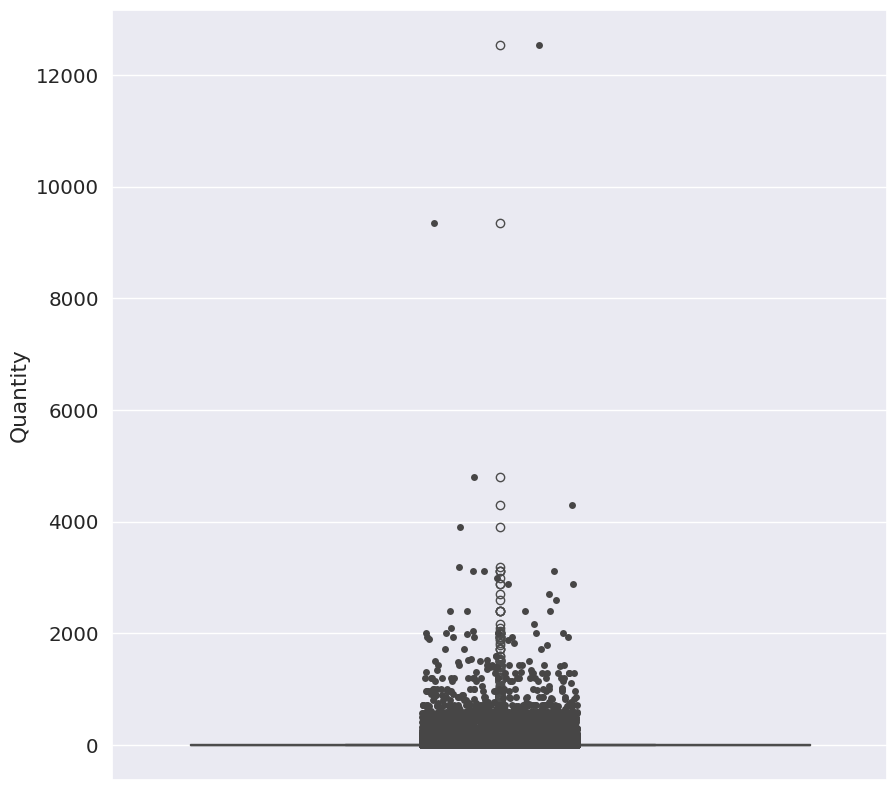

In [17]:
outliers_indices = df.loc[df['Quantity']>20000].index
df = df.drop(outliers_indices)
sns.boxplot( y='Quantity',data=df)
sns.stripplot(y='Quantity',data=df, color="#474646")

<Axes: ylabel='UnitPrice'>

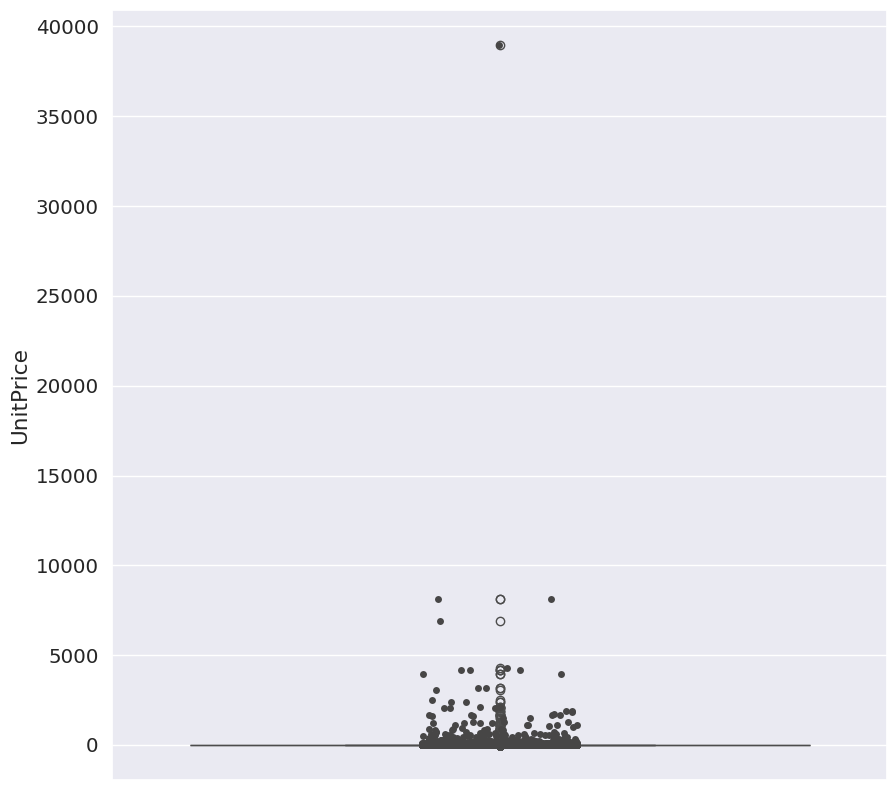

In [18]:
sns.boxplot( y='UnitPrice',data=df)
sns.stripplot(y='UnitPrice',data=df, color="#474646")



*   Drop outliers



<Axes: ylabel='UnitPrice'>

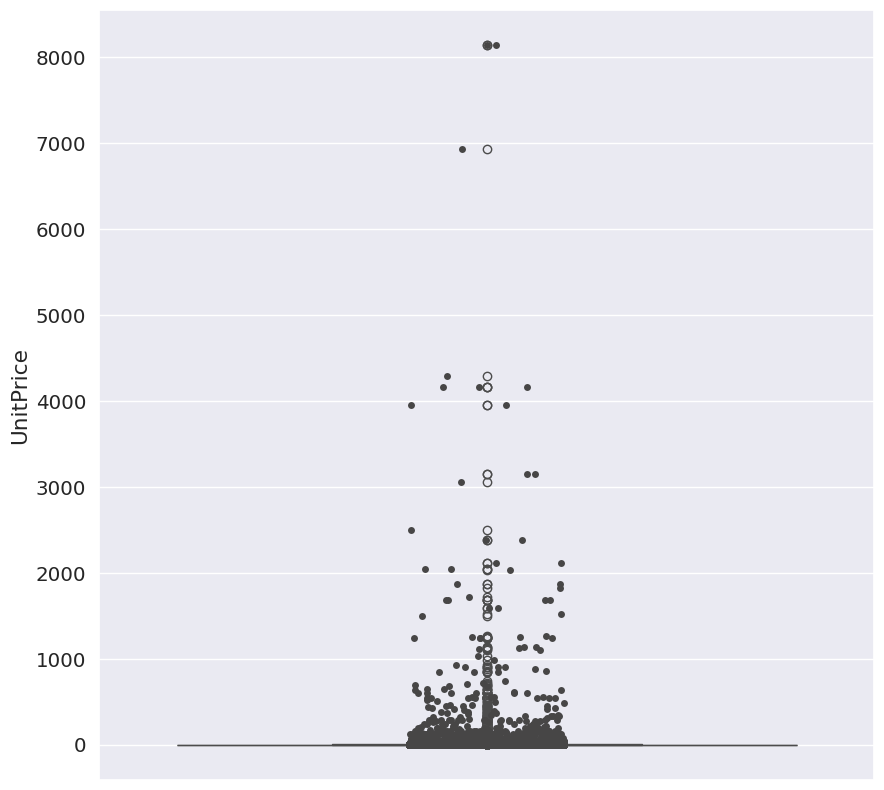

In [19]:
outliers_indices = df.loc[df['UnitPrice']>10000].index
df= df.drop(outliers_indices)
sns.boxplot( y='UnitPrice',data=df)
sns.stripplot(y='UnitPrice',data=df, color="#474646")



*   Recheck again for outliers



In [20]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406824.000000,406824.000000,406824.000000
mean,12.649409,3.364707,15287.699804
std,50.063287,32.746411,1713.596470
min,1.000000,0.000000,12347.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,12540.000000,8142.750000,18287.000000


=>all anomalies have been fixed , so let's fix zero values in UnitPrice column

In [21]:
zero_values = df[df['UnitPrice']==0].index
zero_values

Index([  9302,  33576,  40089,  47068,  47070,  56674,  86789, 130188, 139453,
       145208, 157042, 187613, 198383, 279324, 282912, 285657, 298054, 314745,
       314746, 314747, 314748, 358655, 361825, 379913, 395529, 420404, 436428,
       436597, 436961, 439361, 446125, 446793, 446794, 454463, 454464, 479079,
       479546, 480649, 485985, 502122],
      dtype='int64')

In [22]:
df.drop(zero_values, inplace=True)

In [23]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406784.000000,406784.000000,406784.000000
mean,12.616521,3.365038,15287.805066
std,46.047305,32.748004,1713.569229
min,1.000000,0.001000,12347.000000
25%,2.000000,1.250000,13954.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,9360.000000,8142.750000,18287.000000


# **Data preprocessing**



*   Create profit column



In [24]:
def calculate_profit(x):
    Quantity = x['Quantity']
    UnitPrice = x['UnitPrice']
    profit = Quantity * UnitPrice
    return profit

In [25]:
df['profit']=df[['Quantity','UnitPrice']].apply(calculate_profit,axis=1)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,12/9/11 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,12/9/11 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,12/9/11 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,12/9/11 12:50,4.15,12680.0,France,16.60




*  Create year and month columns



In [26]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [27]:
df['year']=df['InvoiceDate'].dt.year
df['month']=df['InvoiceDate'].dt.month

In [28]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12




*   Enhance the description column readability



In [29]:
df['Description'] = df['Description'].apply(lambda a:a.lower())
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month
0,536365,85123A,white hanging heart t-light holder,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,white metal lantern,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,cream cupid hearts coat hanger,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,knitted union flag hot water bottle,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,red woolly hottie white heart.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12.0,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12
541905,581587,22899,children's apron dolly girl,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12
541906,581587,23254,childrens cutlery dolly girl,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12
541907,581587,23255,childrens cutlery circus parade,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12


# **Data analysis and visiualization**

# **The most sold product and the density of the profit**

In [30]:
df[df["profit"]==df["profit"].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month
222680,556444,22502,picnic basket wicker 60 pieces,60.0,2011-06-10 15:28:00,649.5,15098.0,United Kingdom,38970.0,2011,6


<Axes: xlabel='profit', ylabel='Density'>

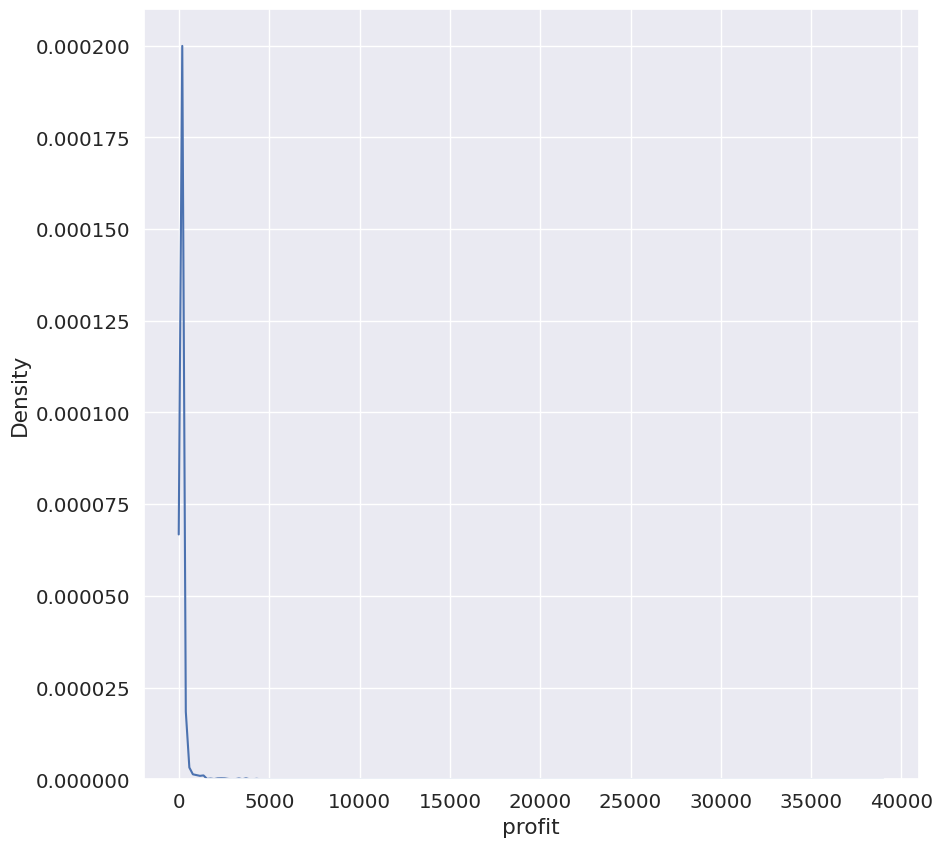

In [31]:
sns.kdeplot(x='profit',data=df)

=> the most sold product was "picnic basket wicker 60 pieces"

# **The least sold product**

In [32]:
df[df["profit"]==df["profit"].min() ]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month
157195,550193,PADS,pads to match all cushions,1.0,2011-04-15 09:27:00,0.001,13952.0,United Kingdom,0.001,2011,4
279045,561226,PADS,pads to match all cushions,1.0,2011-07-26 10:13:00,0.001,15618.0,United Kingdom,0.001,2011,7
359871,568200,PADS,pads to match all cushions,1.0,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,0.001,2011,9
361741,568375,BANK CHARGES,bank charges,1.0,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,0.001,2011,9


# **The most profitable country**

In [33]:
df["Country"].value_counts()

Country
United Kingdom          361849
Germany                   9493
France                    8490
EIRE                      7483
Spain                     2532
Netherlands               2367
Belgium                   2069
Switzerland               1876
Portugal                  1480
Australia                 1256
Norway                    1085
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     250
Unspecified                244
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         57
Lebanon                     45


<Axes: xlabel='count', ylabel='Country'>

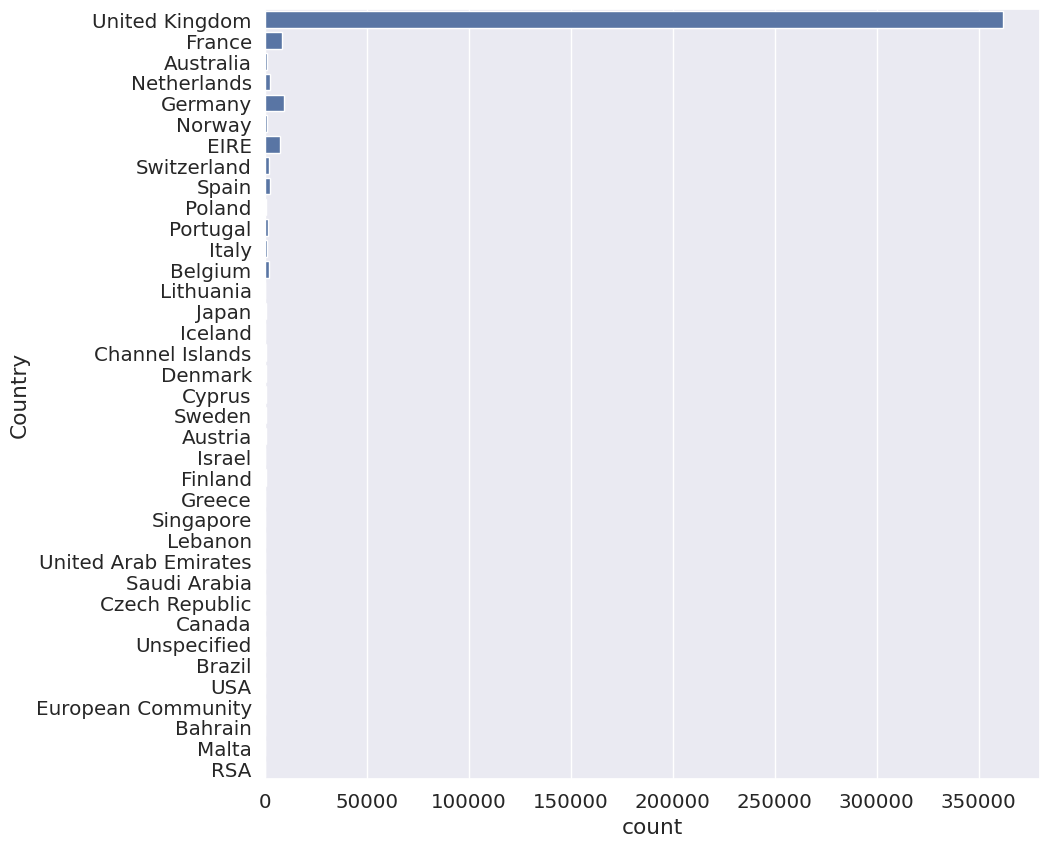

In [34]:
sns.countplot(y='Country',data=df)

=>It is clear that United Kingdom is the most profitable country and this makes sense because most of the branches are located in United Kingdom

# **Average profit for each counrty**

In [35]:
result = df.groupby('Country')['profit'].mean().sort_values(ascending=False)
print(result)

Country
Singapore               146.018297
Netherlands             120.925703
Australia               111.437381
Japan                   110.313184
Sweden                   86.928030
Denmark                  49.209614
Lithuania                47.458857
Lebanon                  37.641778
EIRE                     37.525936
Brazil                   35.737500
Norway                   34.255687
Greece                   32.948767
Finland                  32.756000
Bahrain                  32.258824
Czech Republic           31.525333
Switzerland              30.462953
Israel                   29.796520
United Arab Emirates     27.974706
Channel Islands          27.459881
Spain                    27.006177
France                   26.070113
Portugal                 25.554034
Austria                  25.543741
Germany                  24.864223
Canada                   24.280662
Iceland                  23.681319
Malta                    23.194567
Cyprus                   22.885000
Italy       

<Axes: xlabel='profit', ylabel='Country'>

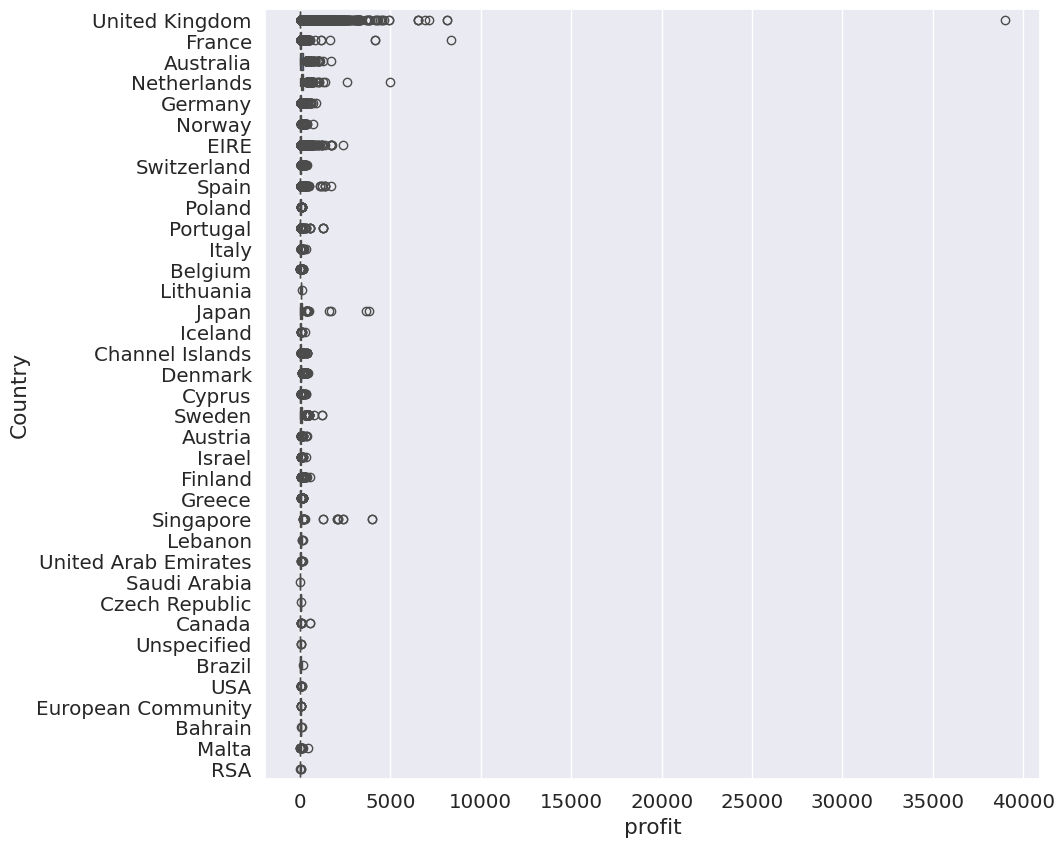

In [36]:
sns.boxplot(y='Country',x='profit',data=df)


# **The earning of each country**

In [37]:
result_sum = df.groupby('Country')['profit'].sum()
print(result_sum)

Country
Australia                139965.350
Austria                   10243.040
Bahrain                     548.400
Belgium                   41481.720
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20814.590
Cyprus                    14234.470
Czech Republic              945.760
Denmark                   19142.540
EIRE                     280806.580
European Community         1308.750
Finland                   22765.420
France                   221335.260
Germany                  236036.070
Greece                     4810.520
Iceland                    4310.000
Israel                     7449.130
Italy                     18075.970
Japan                     39492.120
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2945.710
Netherlands              286231.140
Norway                    37167.420
Poland                     7456.160
Portugal                  37819.970
RSA                 

# **Yearly earning**

In [38]:
result_year_sum = df.groupby('year')['profit'].sum()
print(result_year_sum)

year
2010     590823.760
2011    8401649.834
Name: profit, dtype: float64


<Axes: xlabel='year', ylabel='profit'>

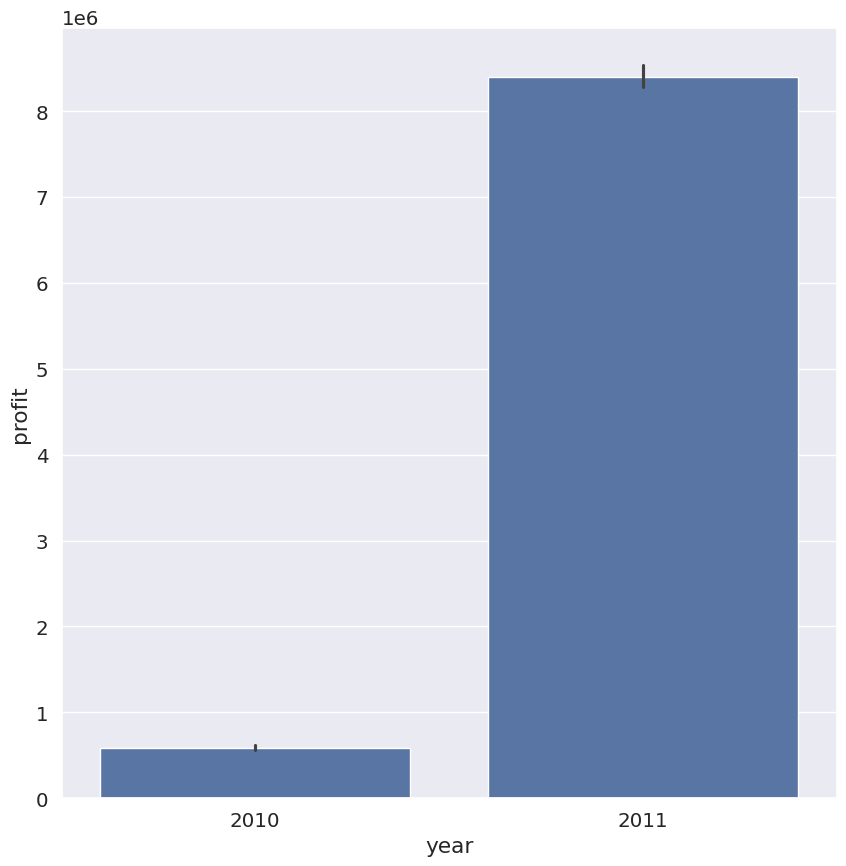

In [39]:
sns.barplot(x='year',y='profit',estimator=np.sum,data=df)

=>this makes sense as most of this data is from 2011

# **The earning of each month in each year**

In [40]:
t_profit = pd.pivot_table(index='year',columns='month',values='profit',data=df,aggfunc=np.sum)
t_profit

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,590823.76
2011,509448.5,457728.55,611036.91,512352.871,708938.04,675444.22,625943.541,674319.8,974236.392,1104033.99,1191227.02,356940.00


# **Highest number of purchase and the money spent on it**

In [41]:
most_orders=df.groupby(["CustomerID","Country"])[["InvoiceNo"]].count().reset_index()
most_orders.sort_values('InvoiceNo',ascending=False).rename(columns={"InvoiceNo":"NumberOf_Orders"}).head()

,CustomerID,Country,NumberOf_Orders
4048,17841.0,United Kingdom,7983
1901,14911.0,EIRE,5901
1306,14096.0,United Kingdom,5128
337,12748.0,United Kingdom,4641
1680,14606.0,United Kingdom,2782


In [42]:
most_money_spent=df.groupby(["CustomerID","Country"])[["profit"]].sum().reset_index()
most_money_spent.sort_values("profit",ascending=False).rename(columns={"profit":"Amount_spent"}).head()

,CustomerID,Country,Amount_spent
1709,14646.0,Netherlands,280923.02
4239,18102.0,United Kingdom,262876.11
3764,17450.0,United Kingdom,201619.41
1901,14911.0,EIRE,155077.50
56,12415.0,Australia,126103.61


# **Top 5 countries with the most number of orders**

In [43]:
country_order=df.groupby("Country")["InvoiceNo"].nunique().reset_index()
country_order=country_order.sort_values("InvoiceNo").rename(columns={"InvoiceNo":"NumberOf_Orders"})
country_order

,Country,NumberOf_Orders
4,Brazil,1
20,Lebanon,1
27,RSA,1
2,Bahrain,2
28,Saudi Arabia,2
34,United Arab Emirates,3
21,Lithuania,4
11,European Community,5
8,Czech Republic,5
5,Canada,6


Text(0.5, 1.0, 'Number of orders for each country')

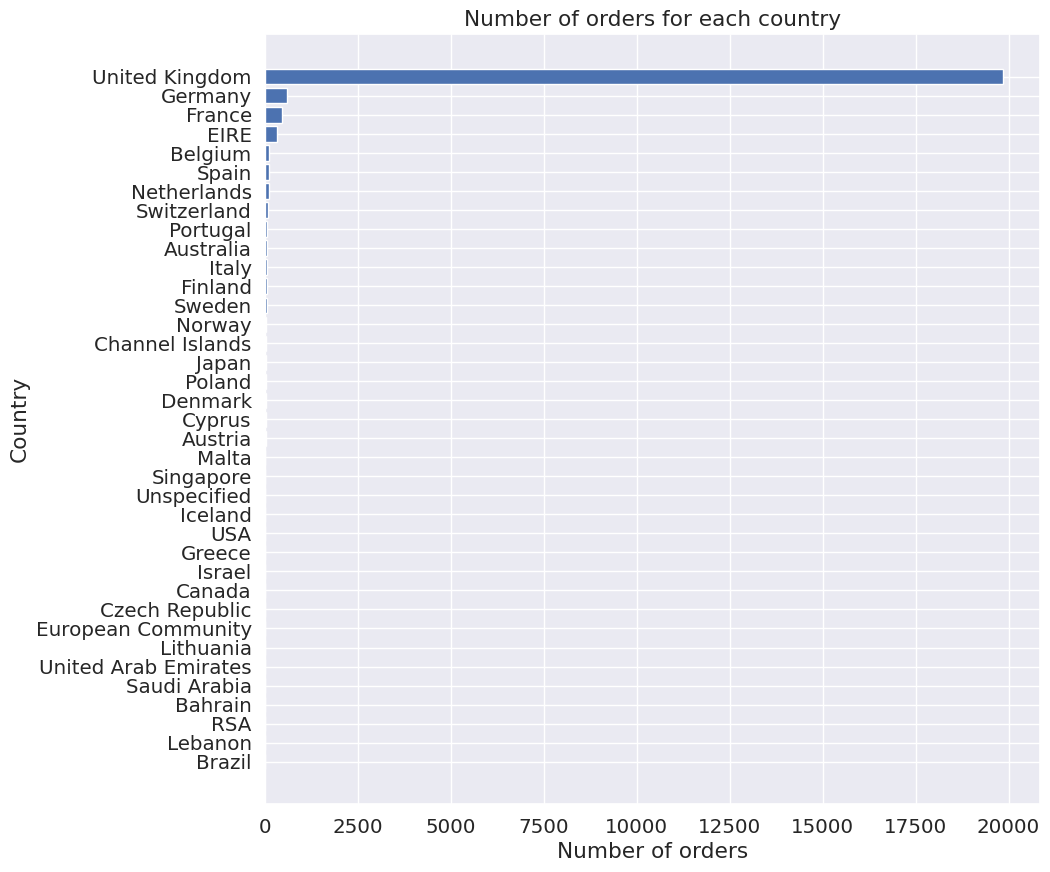

In [44]:
plt.barh(country_order["Country"],country_order["NumberOf_Orders"])
plt.xlabel("Number of orders")
plt.ylabel("Country")
plt.title("Number of orders for each country")

# **Top countries (except UK) with the most number of orders**

Text(0.5, 1.0, 'Number of orders for each country')

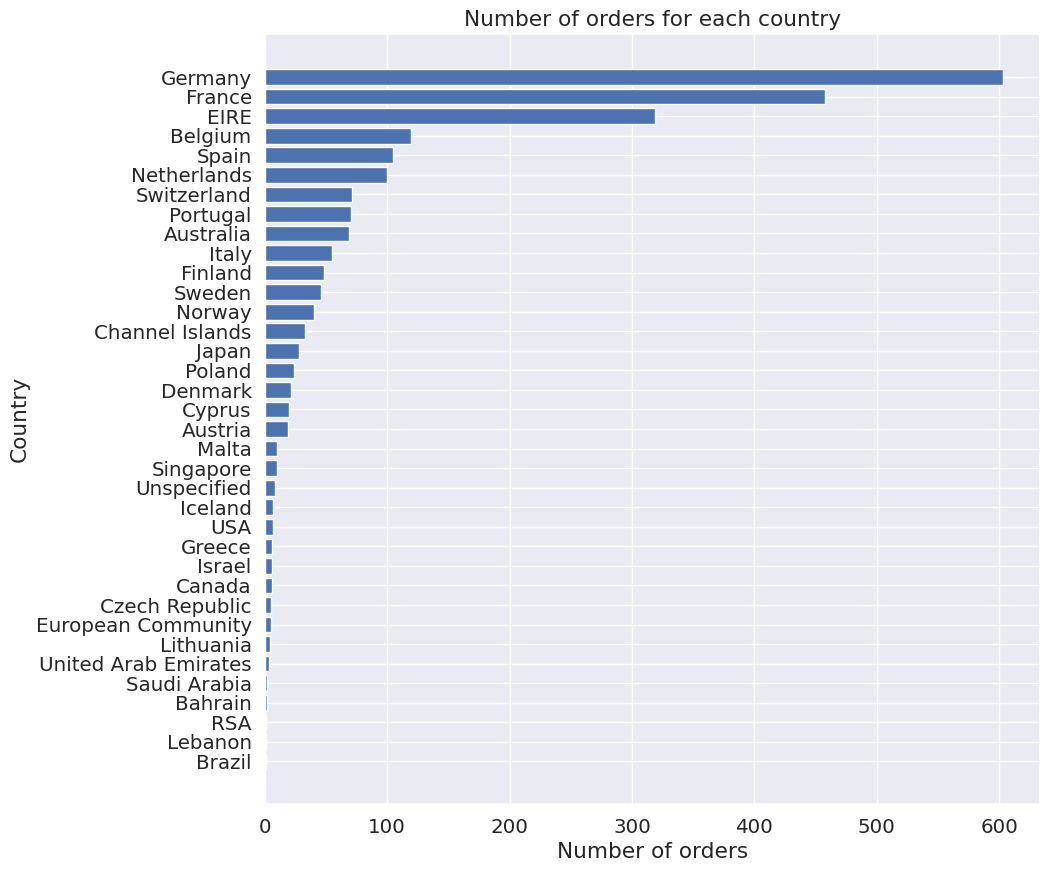

In [45]:
country_without_UK=country_order[country_order["Country"]!="United Kingdom"]
plt.barh(country_without_UK["Country"],country_without_UK["NumberOf_Orders"])
plt.xlabel("Number of orders")
plt.ylabel("Country")
plt.title("Number of orders for each country")

# **Top 5 countries with the highest money spent**

In [46]:
country_spending=df.groupby("Country")["profit"].sum().reset_index()
country_spending=country_spending.sort_values("profit").rename(columns={"profit":"Money_spent"})
country_spending

,Country,Money_spent
28,Saudi Arabia,160.670
2,Bahrain,548.400
8,Czech Republic,945.760
27,RSA,1002.310
4,Brazil,1143.600
11,European Community,1308.750
21,Lithuania,1661.060
20,Lebanon,1693.880
34,United Arab Emirates,1902.280
36,Unspecified,2667.070


([<matplotlib.axis.XTick at 0x7ab0478ef2c0>,
 [Text(0, 0, '0'),
  Text(1000000, 0, '1M'),
  Text(2000000, 0, '2M'),
  Text(3000000, 0, '3M'),
  Text(4000000, 0, '4M'),
  Text(5000000, 0, '5M'),
  Text(6000000, 0, '6M'),
  Text(7000000, 0, '7M')])

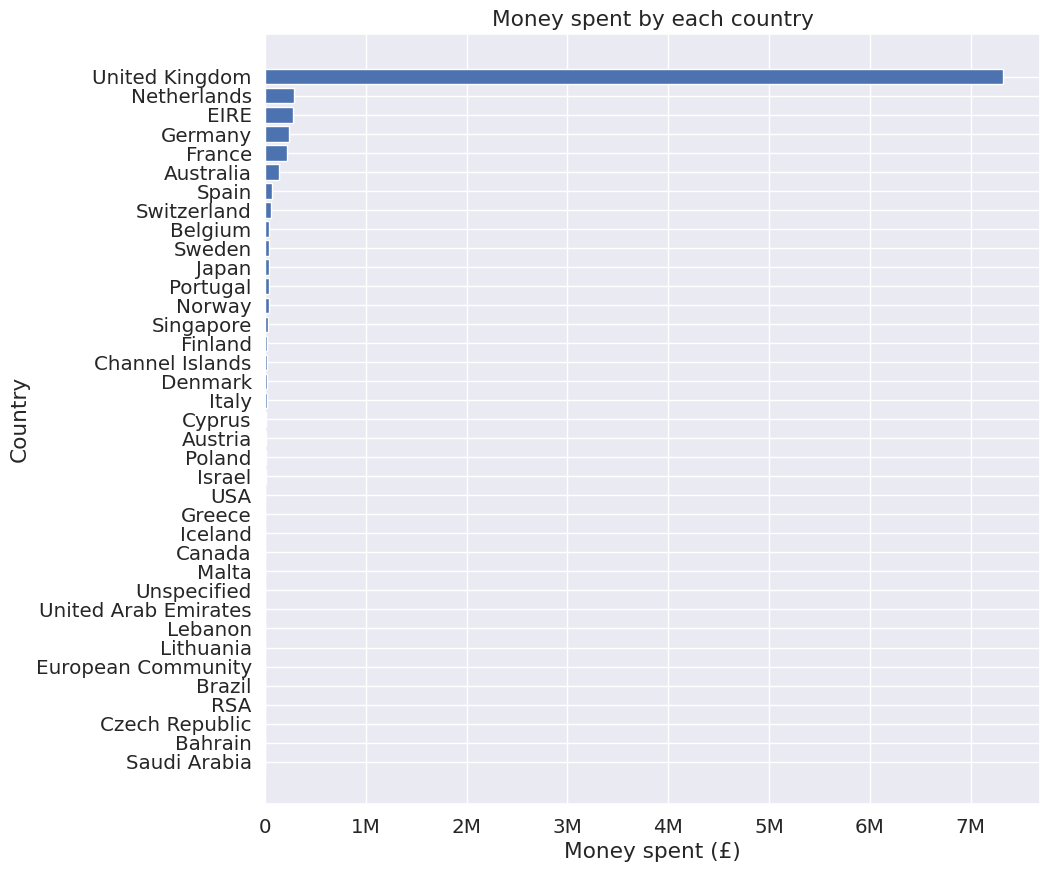

In [47]:
plt.barh(country_spending["Country"],country_spending["Money_spent"])
plt.xlabel("Money spent (£)")
plt.ylabel("Country")
plt.title("Money spent by each country")
plt.xticks(range(0,8000000,1000000),["0","1M","2M","3M","4M","5M","6M","7M"])

# **Top countries(except UK) with the highest money spent**

Text(0.5, 1.0, 'Money spent by each country')

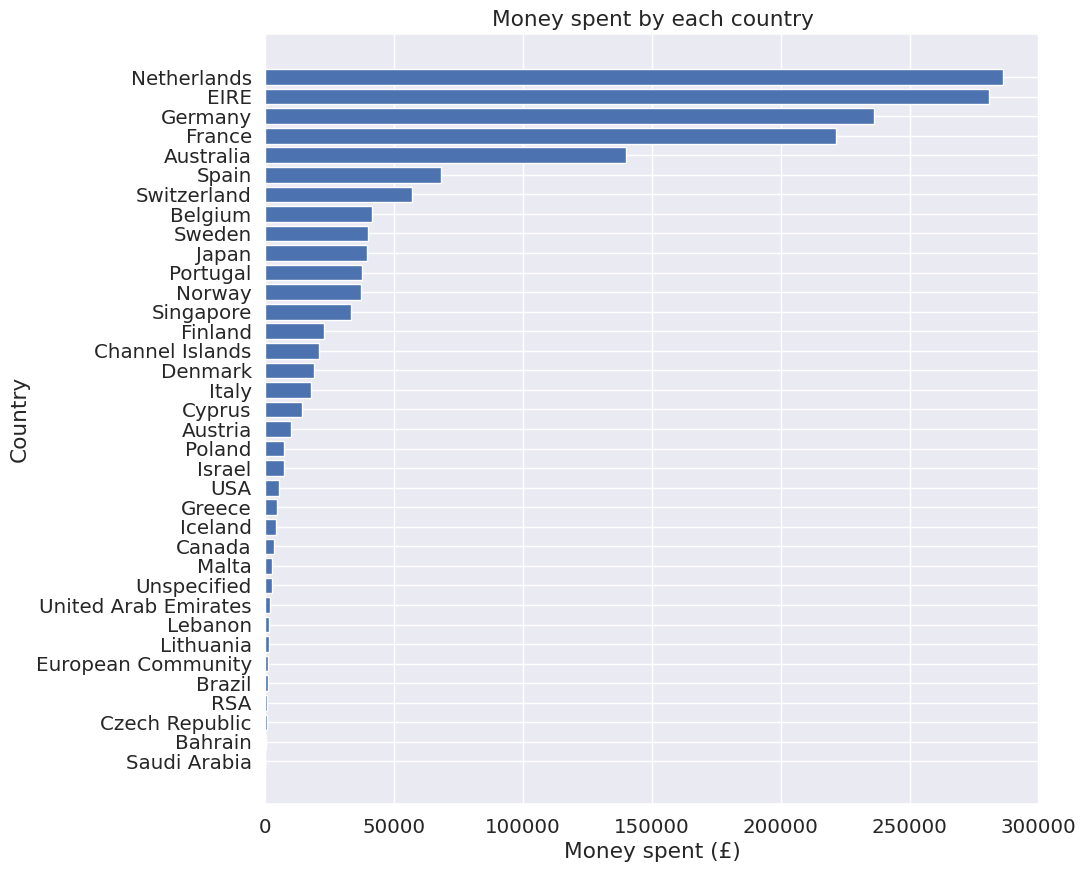

In [48]:
country_spent_without_UK=country_spending[country_spending["Country"]!="United Kingdom"]
plt.barh(country_spent_without_UK["Country"],country_spent_without_UK["Money_spent"])
plt.xlabel("Money spent (£)")
plt.ylabel("Country")
plt.title("Money spent by each country")

# **Top 5 countries with the highest number of customers**

In [49]:
cus_no=df.groupby("Country")["CustomerID"].nunique().reset_index()
cus_no=cus_no.sort_values("CustomerID").rename(columns={"CustomerID":"NumberOf_Customers"})
cus_no

,Country,NumberOf_Customers
4,Brazil,1
8,Czech Republic,1
11,European Community,1
28,Saudi Arabia,1
27,RSA,1
21,Lithuania,1
20,Lebanon,1
16,Iceland,1
29,Singapore,1
22,Malta,2


Text(0, 0.5, 'Country')

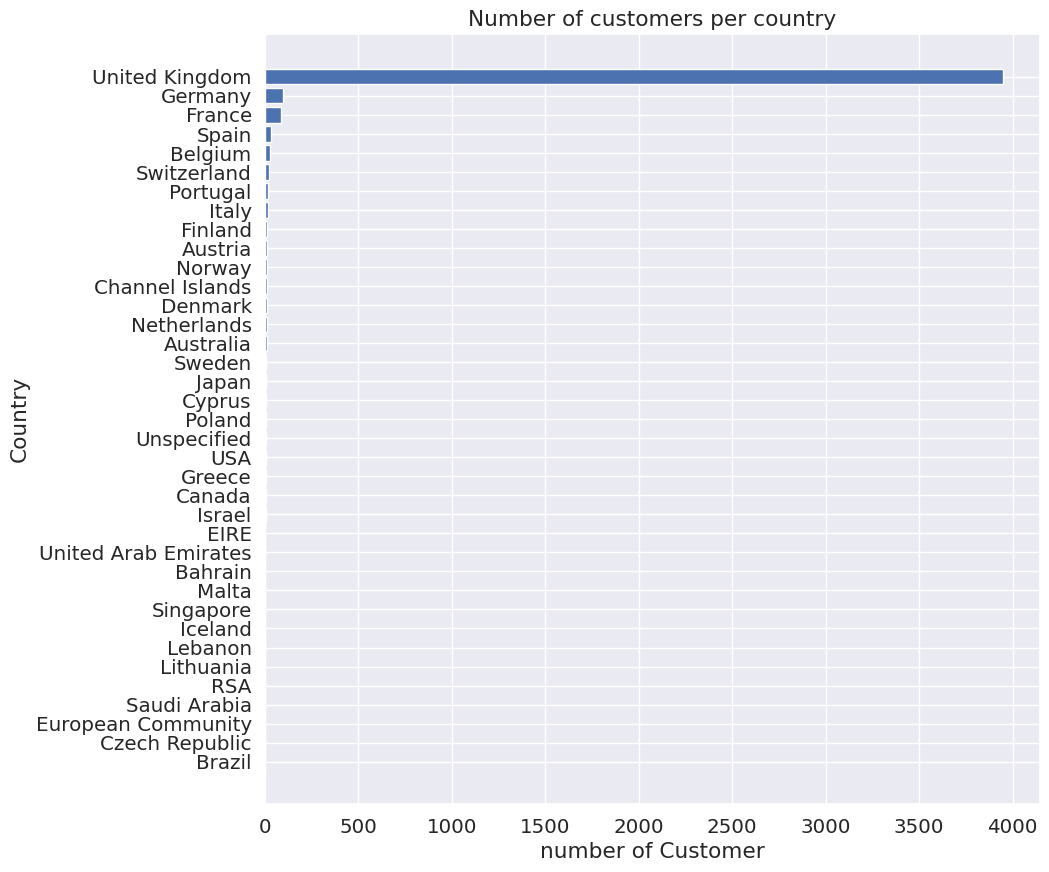

In [50]:
plt.barh(cus_no["Country"],cus_no["NumberOf_Customers"])
plt.title("Number of customers per country")
plt.xlabel("number of Customer")
plt.ylabel("Country")

In [51]:
cus_no.iloc[:-1]

,Country,NumberOf_Customers
4,Brazil,1
8,Czech Republic,1
11,European Community,1
28,Saudi Arabia,1
27,RSA,1
21,Lithuania,1
20,Lebanon,1
16,Iceland,1
29,Singapore,1
22,Malta,2


# **(without UK) Top countries with highest number of customers**

Text(0, 0.5, 'Country')

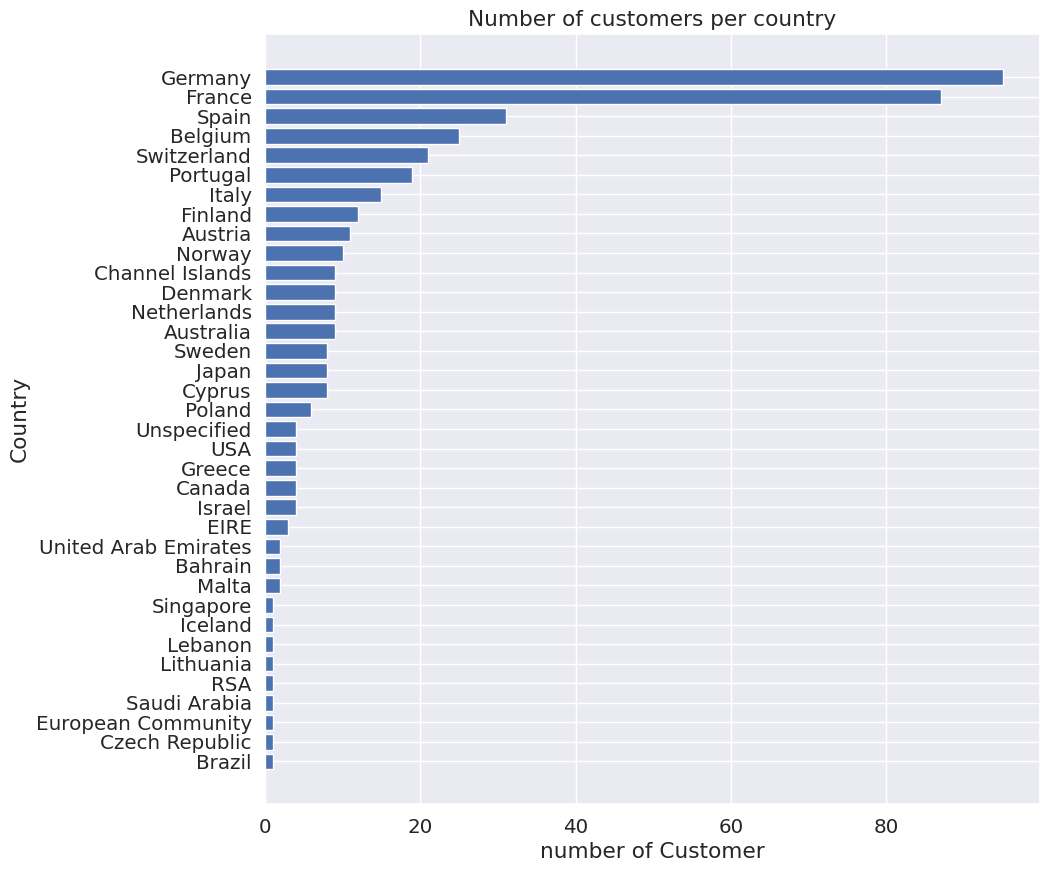

In [52]:
cus_wo_UK=cus_no.iloc[:-1]
plt.barh(cus_wo_UK["Country"],cus_wo_UK["NumberOf_Customers"])
plt.title("Number of customers per country")
plt.xlabel("number of Customer")
plt.ylabel("Country")

# **Number of orders per month**

In [53]:
sort_date=df.sort_values('InvoiceDate')
sort_date["MonthNO"]=sort_date["InvoiceDate"].dt.month
sort_date

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month,MonthNO
0,536365,85123A,white hanging heart t-light holder,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,12
1,536365,71053,white metal lantern,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,12
2,536365,84406B,cream cupid hearts coat hanger,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,12
3,536365,84029G,knitted union flag hot water bottle,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,12
4,536365,84029E,red woolly hottie white heart.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...
541896,581587,22555,plasters in tin strongman,12.0,2011-12-09 12:50:00,1.65,12680.0,France,19.80,2011,12,12
541895,581587,22556,plasters in tin circus parade,12.0,2011-12-09 12:50:00,1.65,12680.0,France,19.80,2011,12,12
541907,581587,23255,childrens cutlery circus parade,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,12
541900,581587,22730,alarm clock bakelike ivory,4.0,2011-12-09 12:50:00,3.75,12680.0,France,15.00,2011,12,12


In [54]:
monthly_order= sort_date.groupby(["MonthNO","month"])["InvoiceNo"].nunique().reset_index()
monthly_order.rename(columns={"InvoiceNo":"NumberOf_Orders"}).drop("MonthNO",axis=1)

,month,NumberOf_Orders
0,1,1234
1,2,1201
2,3,1619
3,4,1384
4,5,1849
5,6,1706
6,7,1593
7,8,1543
8,9,2077
9,10,2263


# **Top 10 Demanded Products By Quantity**

In [55]:
demanded_pro=df.groupby(["StockCode","Description"])["Quantity"].sum().reset_index()
demanded_pro=demanded_pro.sort_values("Quantity",ascending=False).iloc[:10]
demanded_pro

,StockCode,Description,Quantity
3027,84077,world war 2 gliders asstd designs,55615.0
3459,85099B,jumbo bag red retrospot,47296.0
3474,85123A,white hanging heart t-light holder,39303.0
3287,84879,assorted colour bird ornament,35410.0
434,21212,pack of 72 retrospot cake cases,33977.0
1112,22197,popcorn holder,31358.0
2010,23084,rabbit night light,27310.0
1387,22492,mini paint set vintage,26272.0
1509,22616,pack of 12 london tissues,25369.0
930,21977,pack of 60 pink paisley cake cases,24365.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'world war 2 gliders asstd designs'),
  Text(1, 0, 'jumbo bag red retrospot'),
  Text(2, 0, 'white hanging heart t-light holder'),
  Text(3, 0, 'assorted colour bird ornament'),
  Text(4, 0, 'pack of 72 retrospot cake cases'),
  Text(5, 0, 'popcorn holder'),
  Text(6, 0, 'rabbit night light'),
  Text(7, 0, 'mini paint set vintage '),
  Text(8, 0, 'pack of 12 london tissues '),
  Text(9, 0, 'pack of 60 pink paisley cake cases')])

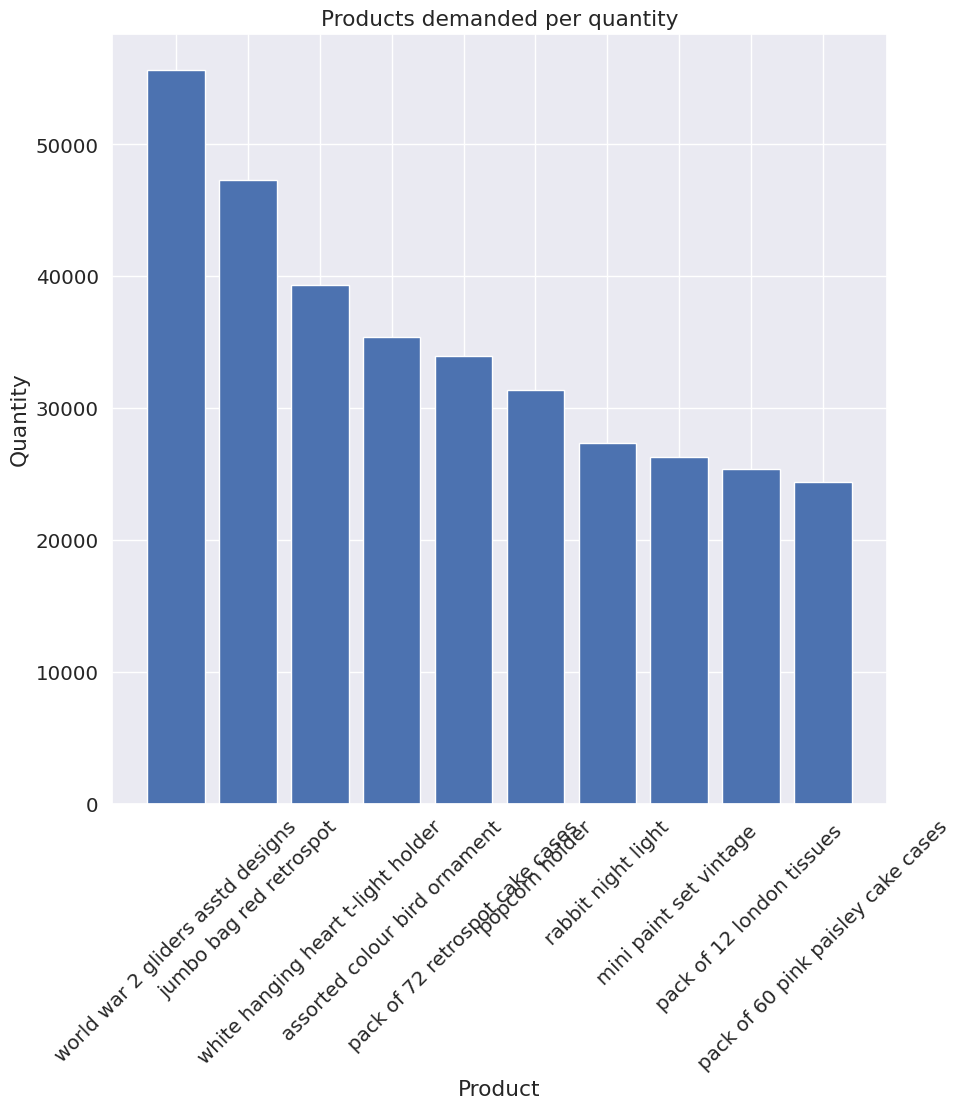

In [56]:
plt.bar(demanded_pro["Description"],demanded_pro["Quantity"])
plt.title("Products demanded per quantity")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45)

# **Top 10 Demanded Products By Sales**

In [57]:
hi_val_p=df.groupby(["StockCode","Description"])["profit"].sum().reset_index().sort_values("profit",ascending=False).iloc[:10]
hi_val_p

,StockCode,Description,profit
1322,22423,regency cakestand 3 tier,152315.50
3912,M,manual,126975.32
3474,85123A,white hanging heart t-light holder,107072.45
3914,POST,postage,88897.68
3459,85099B,jumbo bag red retrospot,87204.80
2804,47566,party bunting,70001.13
3287,84879,assorted colour bird ornament,56661.46
2010,23084,rabbit night light,51554.60
2966,79321,chilli lights,46636.21
1005,22086,paper chain kit 50's christmas,43821.18


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'regency cakestand 3 tier'),
  Text(1, 0, 'manual'),
  Text(2, 0, 'white hanging heart t-light holder'),
  Text(3, 0, 'postage'),
  Text(4, 0, 'jumbo bag red retrospot'),
  Text(5, 0, 'party bunting'),
  Text(6, 0, 'assorted colour bird ornament'),
  Text(7, 0, 'rabbit night light'),
  Text(8, 0, 'chilli lights'),
  Text(9, 0, "paper chain kit 50's christmas ")])

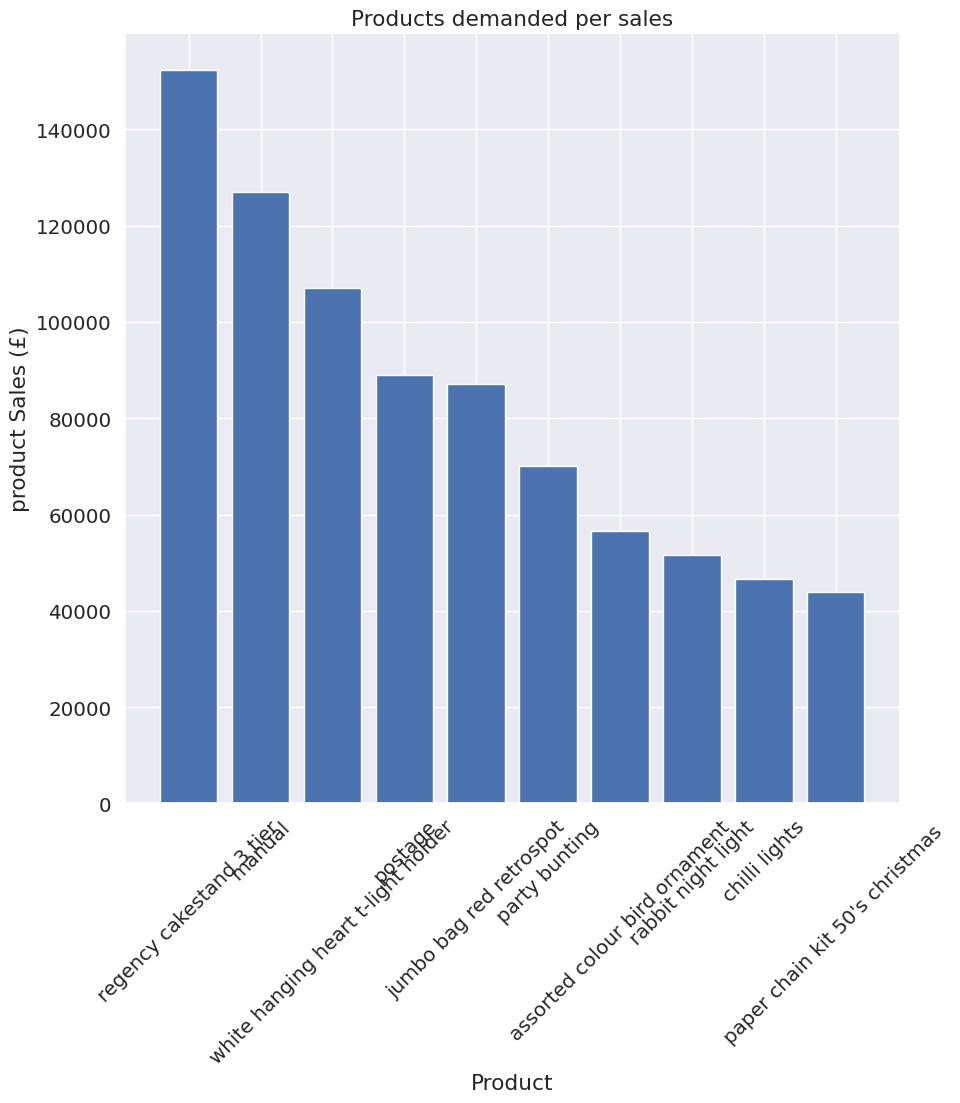

In [58]:
plt.bar(hi_val_p["Description"],hi_val_p["profit"])
plt.title("Products demanded per sales")
plt.xlabel("Product")
plt.ylabel("product Sales (£)")
plt.xticks(rotation=45)

# **Let's use RFM Analysis (Recency, Frequency, Monetary)**



*   Recency => If they bought In recent past
*   Frequency => If they bought many times
*   Monetary => If they spent bigger


In [59]:
df1=df.groupby(df["CustomerID"])["profit"].sum()
df1=df1.reset_index()
df1.columns=["CustomerID","Monetary"]
df1

,CustomerID,Monetary
0,12347.0,4310.00
1,12348.0,1797.24
2,12349.0,1757.55
3,12350.0,334.40
4,12352.0,3466.67
...,...,...
4365,18280.0,180.60
4366,18281.0,80.82
4367,18282.0,179.50
4368,18283.0,2094.88


In [60]:
df2 =df.groupby(df["CustomerID"])["InvoiceNo"].count()
df2 =df2 .reset_index()
df2.columns = ['CustomerID', 'frequency']
df2

,CustomerID,frequency
0,12347.0,182
1,12348.0,31
2,12349.0,73
3,12350.0,17
4,12352.0,95
...,...,...
4365,18280.0,10
4366,18281.0,7
4367,18282.0,13
4368,18283.0,756


In [61]:
rmf_df = pd.merge(df1, df2, on='CustomerID', how='inner')
rmf_df

,CustomerID,Monetary,frequency
0,12347.0,4310.00,182
1,12348.0,1797.24,31
2,12349.0,1757.55,73
3,12350.0,334.40,17
4,12352.0,3466.67,95
...,...,...,...
4365,18280.0,180.60,10
4366,18281.0,80.82,7
4367,18282.0,179.50,13
4368,18283.0,2094.88,756


In [62]:
last_date = max(df['InvoiceDate'])
df['diff_in_days'] = last_date - df['InvoiceDate']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,profit,year,month,diff_in_days
0,536365,85123A,white hanging heart t-light holder,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,373 days 04:24:00
1,536365,71053,white metal lantern,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,373 days 04:24:00
2,536365,84406B,cream cupid hearts coat hanger,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,373 days 04:24:00
3,536365,84029G,knitted union flag hot water bottle,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,373 days 04:24:00
4,536365,84029E,red woolly hottie white heart.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,373 days 04:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12.0,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,0 days 00:00:00
541905,581587,22899,children's apron dolly girl,6.0,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,0 days 00:00:00
541906,581587,23254,childrens cutlery dolly girl,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,0 days 00:00:00
541907,581587,23255,childrens cutlery circus parade,4.0,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,0 days 00:00:00


In [63]:
last_purchase = df.groupby('CustomerID')['diff_in_days'].min()
last_purchase = last_purchase.reset_index()
last_purchase

,CustomerID,diff_in_days
0,12347.0,1 days 20:58:00
1,12348.0,74 days 23:37:00
2,12349.0,18 days 02:59:00
3,12350.0,309 days 20:49:00
4,12352.0,35 days 22:13:00
...,...,...
4365,18280.0,277 days 02:58:00
4366,18281.0,180 days 01:57:00
4367,18282.0,7 days 01:07:00
4368,18283.0,3 days 00:48:00


In [64]:
rmf_df = pd.merge(rmf_df, last_purchase, on='CustomerID', how='inner')
rmf_df.columns = ['CustomerID', 'monetary', 'frequency', 'recency']
rmf_df

,CustomerID,monetary,frequency,recency
0,12347.0,4310.00,182,1 days 20:58:00
1,12348.0,1797.24,31,74 days 23:37:00
2,12349.0,1757.55,73,18 days 02:59:00
3,12350.0,334.40,17,309 days 20:49:00
4,12352.0,3466.67,95,35 days 22:13:00
...,...,...,...,...
4365,18280.0,180.60,10,277 days 02:58:00
4366,18281.0,80.82,7,180 days 01:57:00
4367,18282.0,179.50,13,7 days 01:07:00
4368,18283.0,2094.88,756,3 days 00:48:00


In [65]:
rmf_df['recency'] = rmf_df['recency'].dt.days
rmf_df

,CustomerID,monetary,frequency,recency
0,12347.0,4310.00,182,1
1,12348.0,1797.24,31,74
2,12349.0,1757.55,73,18
3,12350.0,334.40,17,309
4,12352.0,3466.67,95,35
...,...,...,...,...
4365,18280.0,180.60,10,277
4366,18281.0,80.82,7,180
4367,18282.0,179.50,13,7
4368,18283.0,2094.88,756,3


# **Machine learning model**

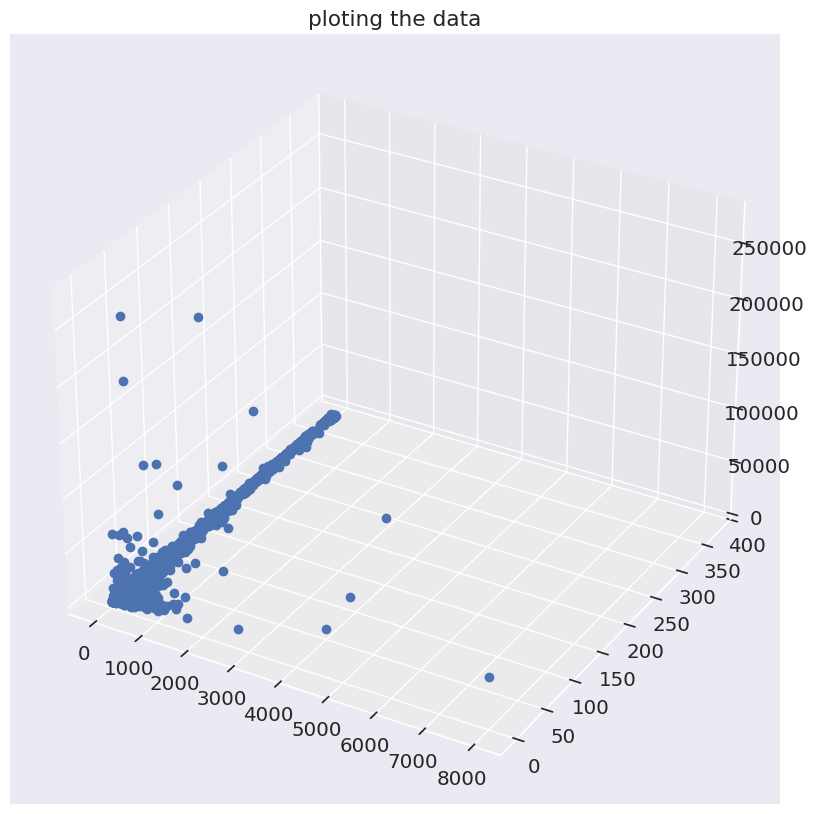

In [66]:
# showing the data
from mpl_toolkits import mplot3d

fig = plt.figure()

# syntax for 3-D projection
ax = plt.axes(projection ='3d')

# defining all 3 axes
z =rmf_df['monetary']
x = rmf_df['frequency']
y = rmf_df['recency']

# plotting
ax.plot3D(x, y, z,'o')
ax.set_title('ploting the data')
plt.show()

**Feature scaling**

In [67]:
scaler=StandardScaler()
df_scaled = rmf_df[['monetary', 'frequency', 'recency']]
df_scaled = scaler.fit_transform(df_scaled)
df_scaled

array([[ 0.2544644 ,  0.38249347, -0.8942059 ],
       [-0.02943608, -0.26708076, -0.16937551],
       [-0.0339204 , -0.08640449, -0.72540978],
       ...,
       [-0.21221404, -0.34451345, -0.8346308 ],
       [ 0.00419234,  2.85173593, -0.87434753],
       [-0.02491222, -0.09930994, -0.48710938]])

In [68]:
scaled_data = pd.DataFrame(df_scaled)
scaled_data.columns = ['monetary', 'frequency', 'recency']
scaled_data.head()

,monetary,frequency,recency
0,0.254464,0.382493,-0.894206
1,-0.029436,-0.267081,-0.169376
2,-0.033920,-0.086404,-0.725410
3,-0.194713,-0.327306,2.163983
4,0.159182,0.008235,-0.556614


**now we will be using the K-mean model**

**But, first let's find the best number of clusters**

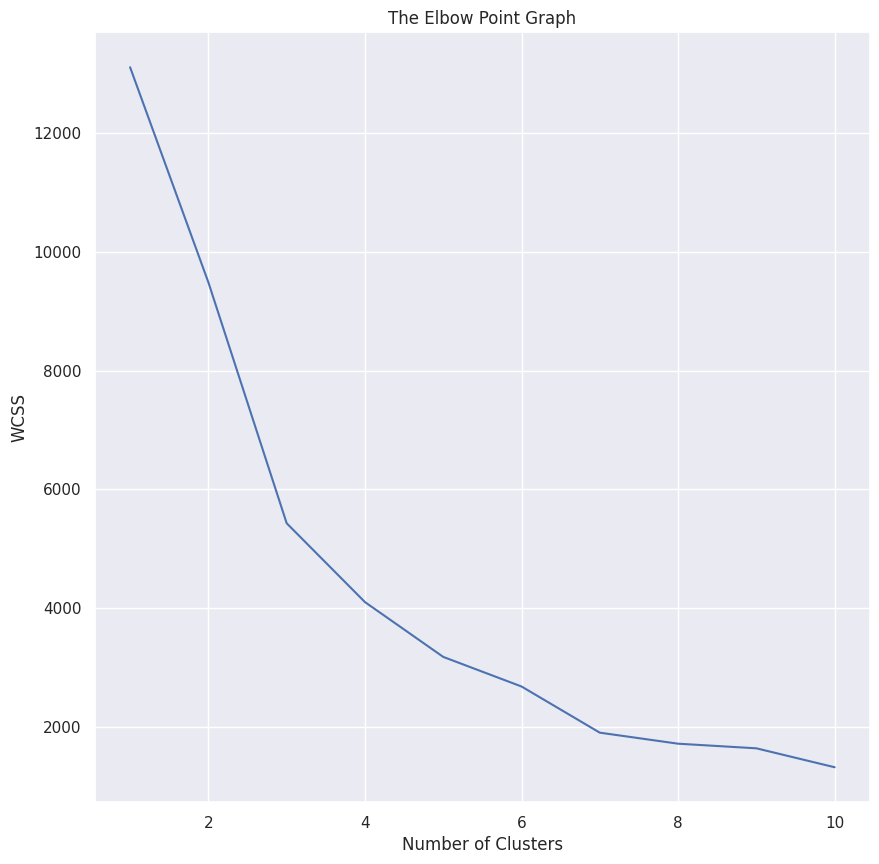

In [69]:
wcss_list = []
for i in range(1,11):

  kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42)

  kmeans_model.fit(scaled_data)

  wcss_list.append(kmeans_model.inertia_)

sns.set()
plt.plot(range(1,11), wcss_list)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

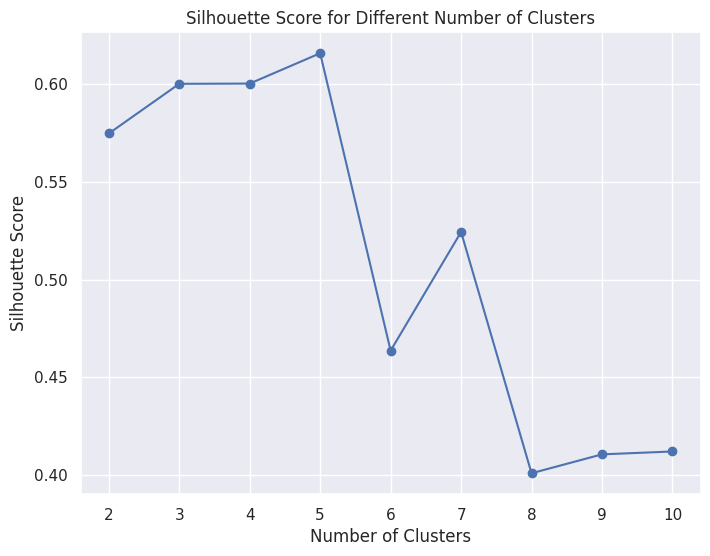

Optimal number of clusters based on silhouette score: 5


In [70]:
from sklearn.metrics import silhouette_score
import numpy as np

sil_scores = []

for i in range(2, 11):  # Start from 2 since silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    sil_scores.append(score)

# Plotting the Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores, marker='o', color='b')
plt.title('Silhouette Score for Different Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Print the best k based on silhouette score
best_k = np.argmax(sil_scores) + 2  # +2 because we started from 2
print(f"Optimal number of clusters based on silhouette score: {best_k}")


Obviously, the best number is 5, as the WCSS continues to decrease sharply up to
k=4, but at k=5, the reduction in WCSS becomes less significant.               However, choosing k=5 still provides a clear separation between clusters, offering a more detailed segmentation that helps uncover deeper insights.

In [71]:
KMeans_Model = KMeans(n_clusters= 5 ,
                      random_state=4 ,
                      max_iter=300 ,
                      tol=0.0001)
KMeans_Model.fit(scaled_data)

print('KMeansModel centers are : ' , KMeans_Model.cluster_centers_)
print('---------------------------------------------------')
print('KMeansModel labels are : ' , KMeans_Model.labels_[:20])
print('---------------------------------------------------')
print('KMeansModel intertia is : ' , KMeans_Model.inertia_)
print('---------------------------------------------------')

KMeansModel centers are :  [[-0.0814918  -0.08452846 -0.48151031]
 [-0.17645643 -0.28082234  1.56862316]
 [ 8.47559435 25.03727715 -0.8942059 ]
 [19.10308134  3.53941196 -0.7906587 ]
 [ 1.03764057  1.66968689 -0.77367023]]
---------------------------------------------------
KMeansModel labels are :  [0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0]
---------------------------------------------------
KMeansModel intertia is :  3030.5296945109703
---------------------------------------------------


In [72]:
len(set(KMeans_Model.labels_))

5

In [73]:
rmf_df['cluster_ID'] =  KMeans_Model.labels_
rmf_df

,CustomerID,monetary,frequency,recency,cluster_ID
0,12347.0,4310.00,182,1,0
1,12348.0,1797.24,31,74,0
2,12349.0,1757.55,73,18,0
3,12350.0,334.40,17,309,1
4,12352.0,3466.67,95,35,0
...,...,...,...,...,...
4365,18280.0,180.60,10,277,1
4366,18281.0,80.82,7,180,1
4367,18282.0,179.50,13,7,0
4368,18283.0,2094.88,756,3,4


In [74]:
cluster_1 =rmf_df[rmf_df['cluster_ID']==0]
cluster_1

,CustomerID,monetary,frequency,recency,cluster_ID
0,12347.0,4310.00,182,1,0
1,12348.0,1797.24,31,74,0
2,12349.0,1757.55,73,18,0
4,12352.0,3466.67,95,35,0
8,12356.0,2811.43,59,22,0
...,...,...,...,...,...
4362,18276.0,348.36,16,20,0
4363,18277.0,123.13,9,57,0
4364,18278.0,173.90,9,73,0
4367,18282.0,179.50,13,7,0


In [75]:
cluster_2 =rmf_df[rmf_df['cluster_ID']==1]
cluster_2

,CustomerID,monetary,frequency,recency,cluster_ID
3,12350.0,334.40,17,309,1
5,12353.0,89.00,4,203,1
6,12354.0,1079.40,58,231,1
7,12355.0,459.40,13,213,1
13,12361.0,189.90,10,286,1
...,...,...,...,...,...
4348,18256.0,50.10,4,354,1
4351,18260.0,2691.40,140,172,1
4357,18269.0,198.30,8,357,1
4365,18280.0,180.60,10,277,1


In [76]:
cluster_3 =rmf_df[rmf_df['cluster_ID']==2]
cluster_3

,CustomerID,monetary,frequency,recency,cluster_ID
329,12748.0,38367.36,4641,0,2
1298,14096.0,73208.67,5128,3,2
1893,14911.0,155077.50,5901,0,2
4040,17841.0,41642.36,7983,1,2


In [77]:
cluster_4 =rmf_df[rmf_df['cluster_ID']==3]
cluster_4

,CustomerID,monetary,frequency,recency,cluster_ID
54,12415.0,126103.61,776,23,3
1343,14156.0,121375.12,1420,9,3
1701,14646.0,280923.02,2081,1,3
2720,16029.0,111057.07,274,38,3
3756,17450.0,201619.41,351,7,3
3799,17511.0,93999.38,1076,2,3
4231,18102.0,262876.11,433,0,3


In [78]:
cluster_5 =rmf_df[rmf_df['cluster_ID']==4]
cluster_5

,CustomerID,monetary,frequency,recency,cluster_ID
65,12428.0,8035.72,300,25,4
70,12433.0,13375.87,420,0,4
85,12451.0,9137.52,355,10,4
99,12471.0,20907.18,531,1,4
100,12472.0,6914.74,391,30,4
...,...,...,...,...,...
4243,18118.0,5711.87,1284,10,4
4247,18122.0,1826.21,364,7,4
4322,18223.0,6653.85,299,1,4
4324,18225.0,5657.22,286,2,4


**Now let's explore the clusters(Frequency, Recency and Monetary)**

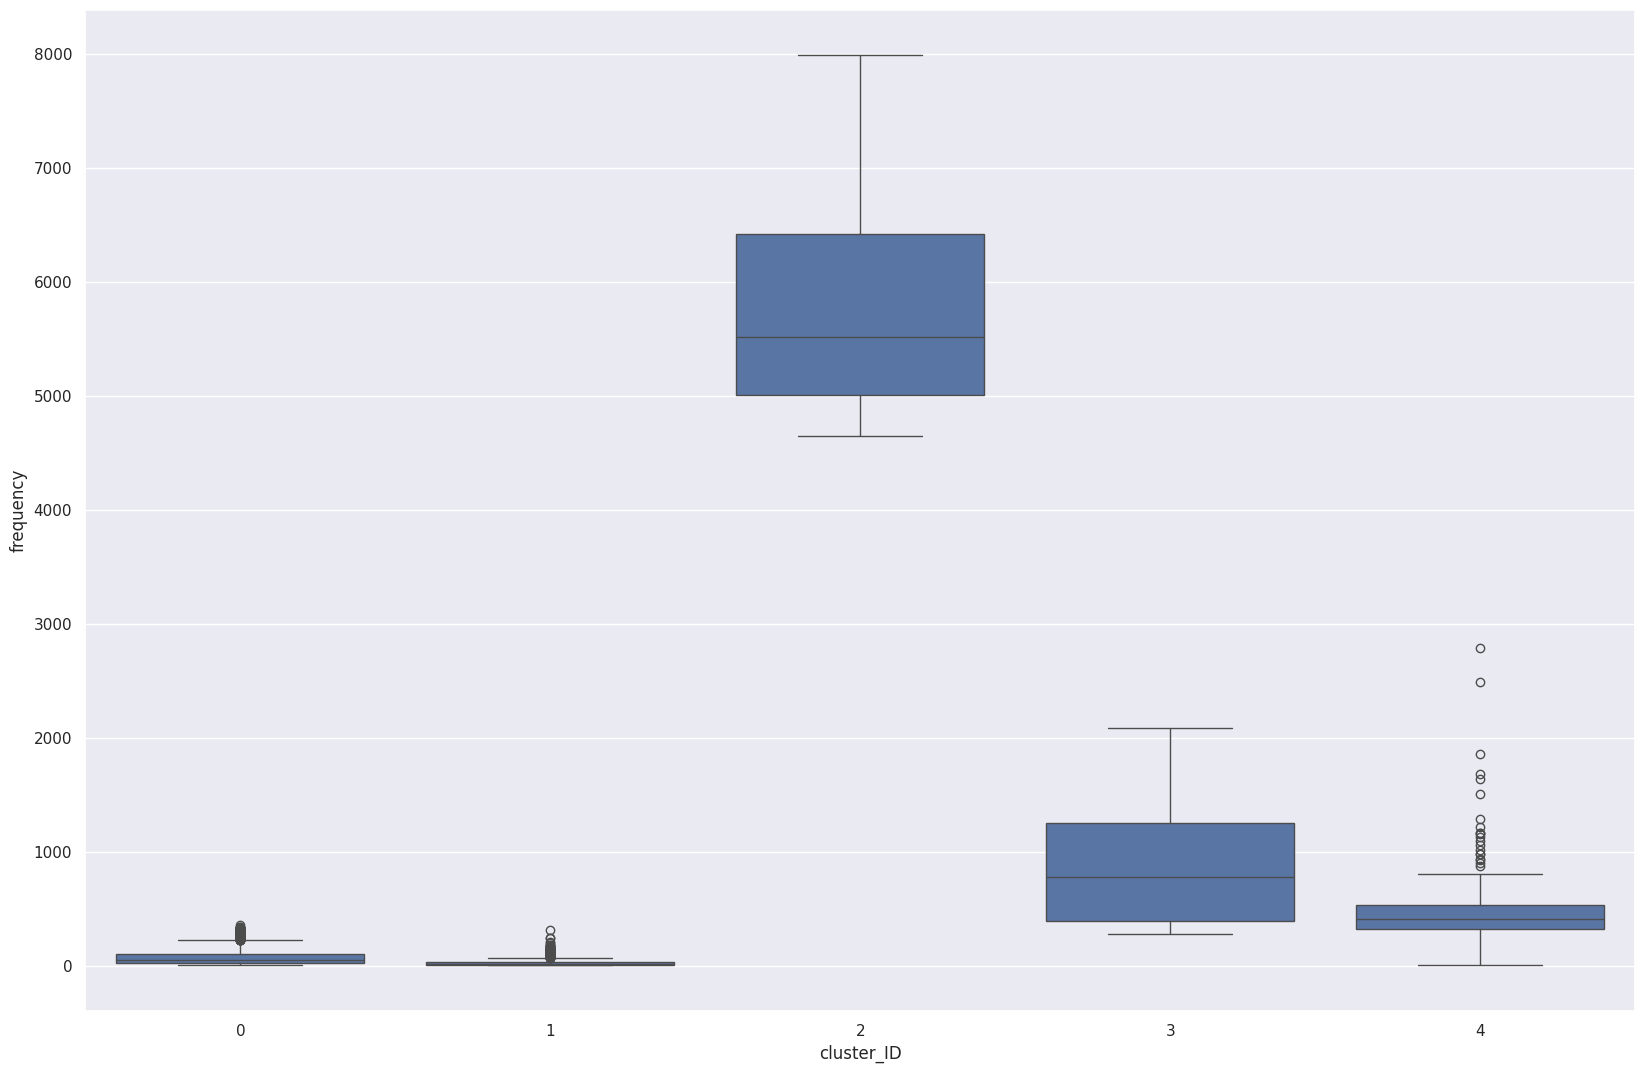

In [79]:
fig=plt.figure(figsize=(20,13))
ax=sns.boxplot(x='cluster_ID', y='frequency', data=rmf_df)
fig.show()

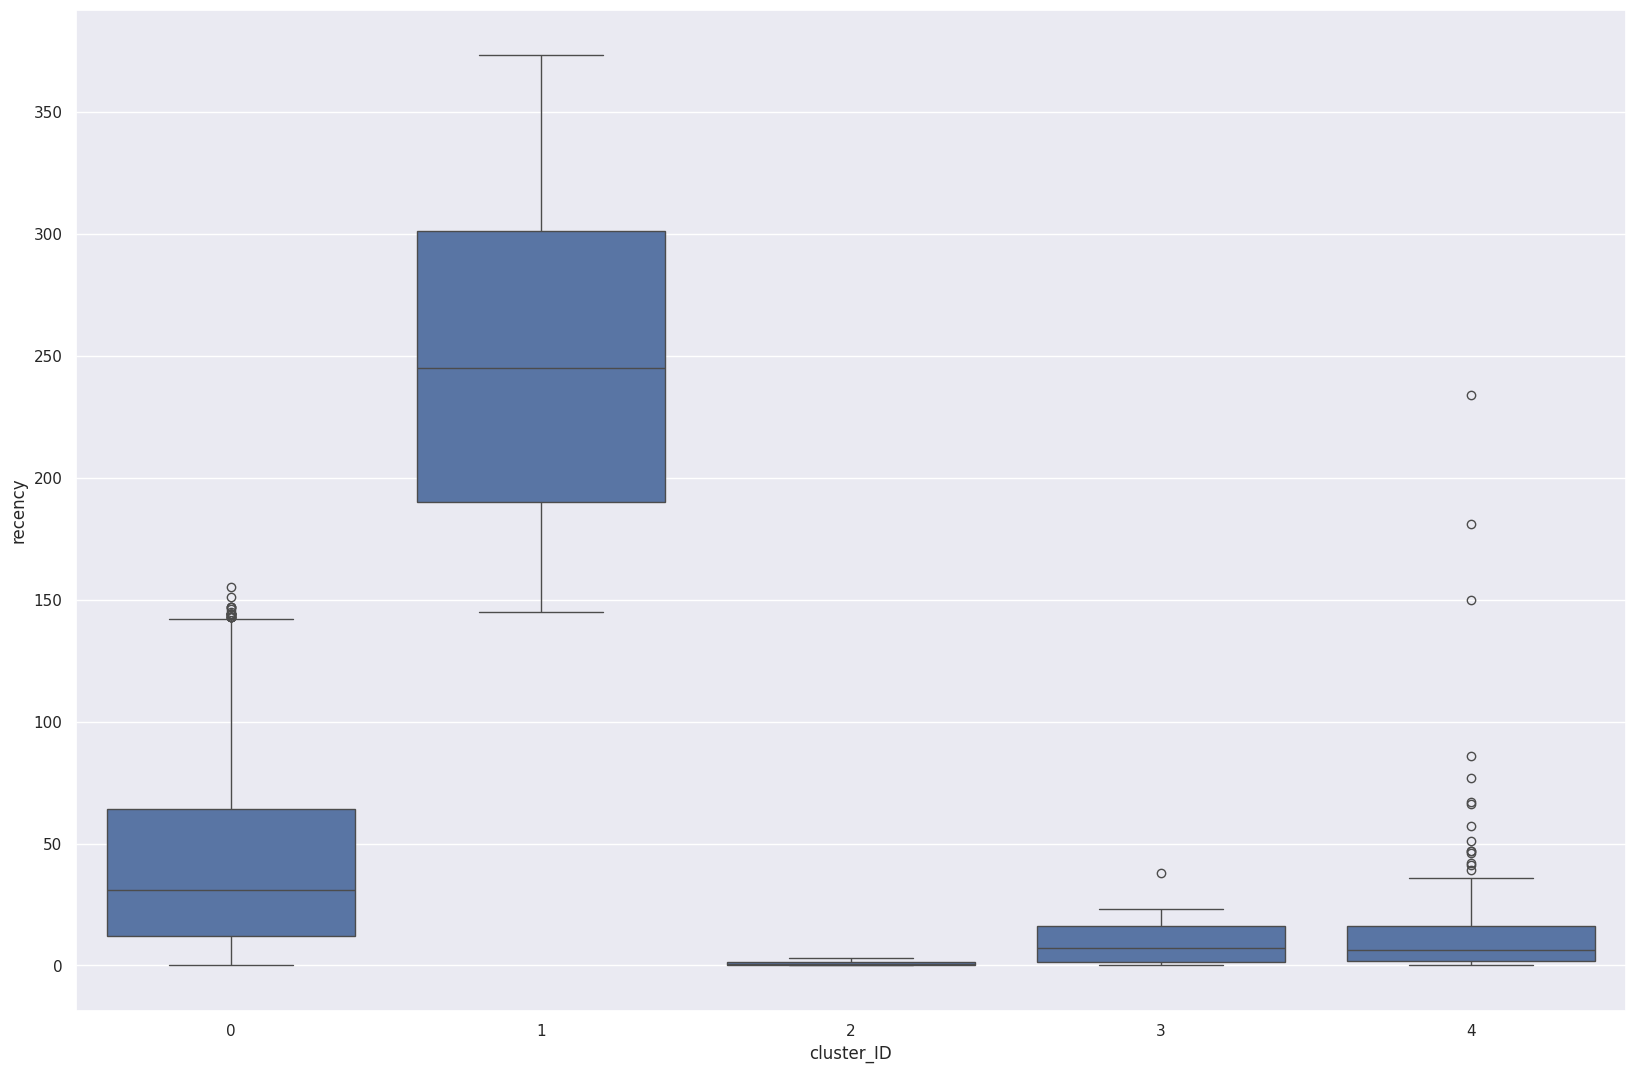

In [80]:
fig=plt.figure(figsize=(20,13))
ax=sns.boxplot(x='cluster_ID', y='recency', data=rmf_df)
fig.show()

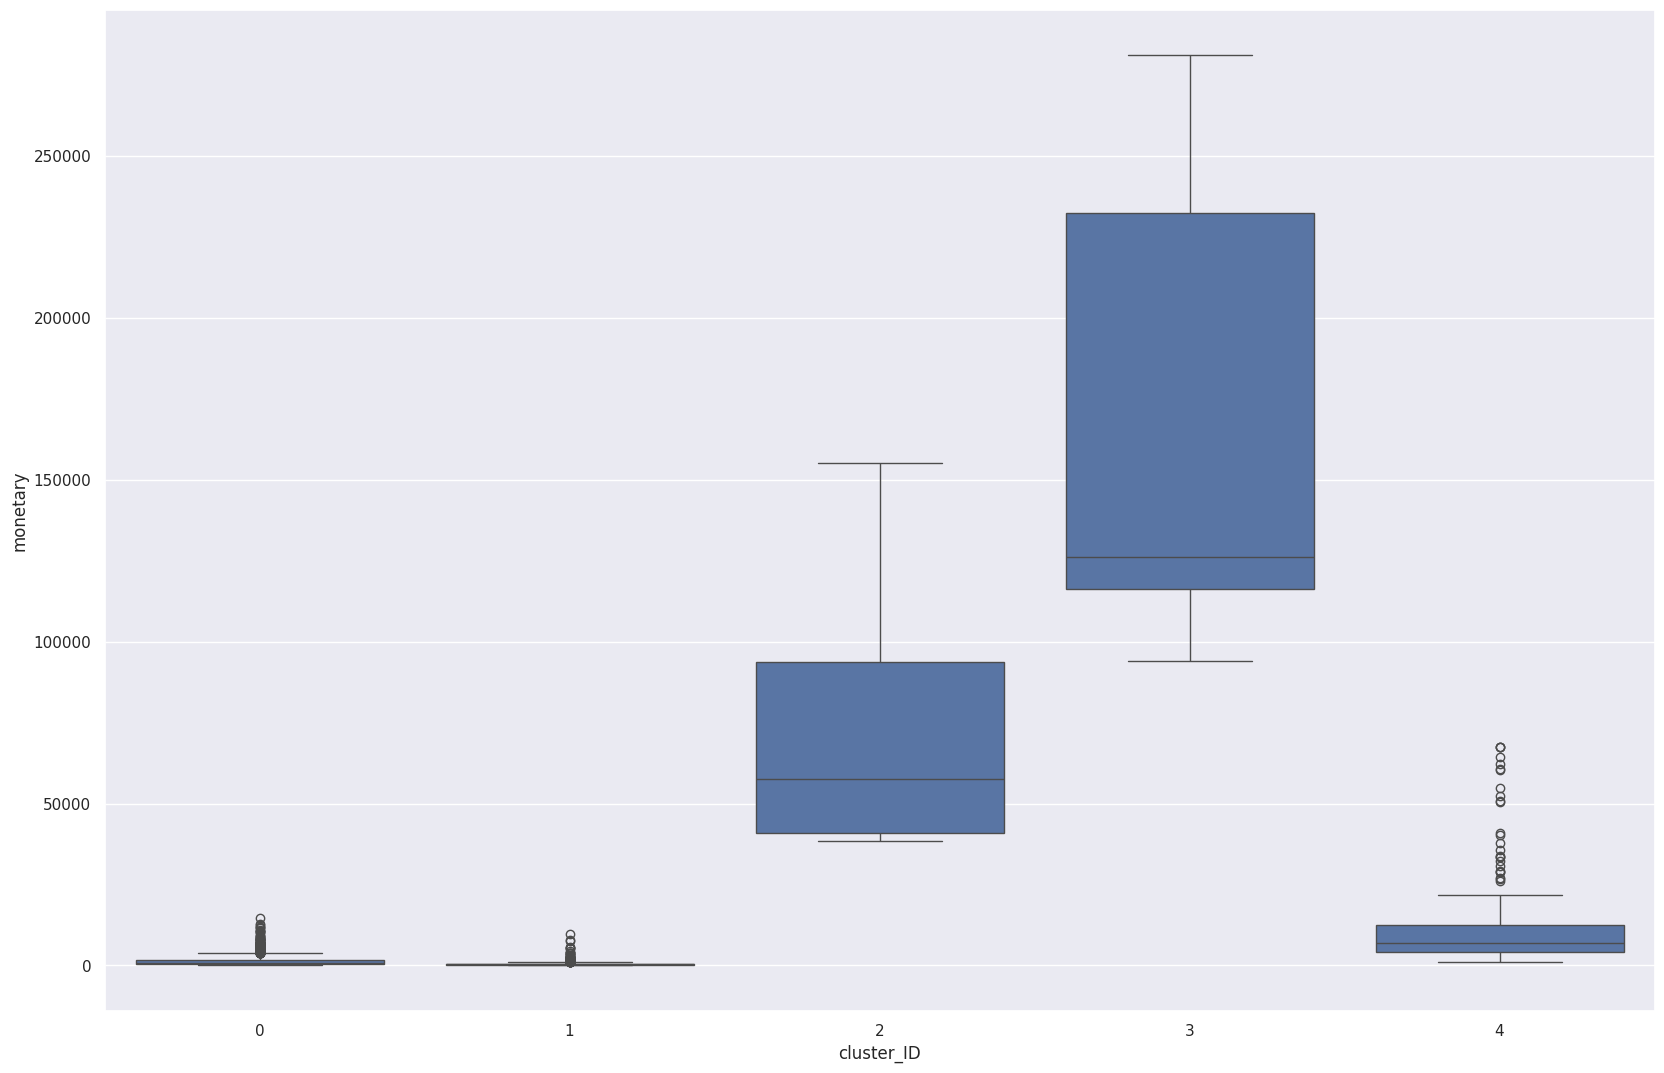

In [81]:
fig=plt.figure(figsize=(20,13))
ax=sns.boxplot(x='cluster_ID', y='monetary', data=rmf_df)
fig.show()

=>So we can see that cluster 3, is our MVP customers that have generated the most revenue having Spent the most money in the products of the store.

**Testing**

In [82]:
test_data = [200,10,20]
test_data=scaler.transform([test_data])
KMeans_Model.predict(test_data)

array([0], dtype=int32)

In [83]:
test_data = [15000,8000,100]
test_data=scaler.transform([test_data])
KMeans_Model.predict(test_data)

array([2], dtype=int32)

In [84]:
import plotly.graph_objects as go
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Fit the KMeans model to your scaled data (you can change the n_clusters as needed)
KMeans_Model = KMeans(n_clusters=5, random_state=4, max_iter=300, tol=0.0001)
KMeans_Model.fit(scaled_data)

# Get cluster labels for each data point
labels = KMeans_Model.labels_

# If 'scaled_data' is a pandas DataFrame, use .iloc to access the columns
x = scaled_data.iloc[:, 0]  # Recency (first column)
y = scaled_data.iloc[:, 1]  # Frequency (second column)
z = scaled_data.iloc[:, 2]  # Monetary (third column)

# Create the 3D scatter plot
Scene = dict(xaxis=dict(title='Recency'),
             yaxis=dict(title='Frequency'),
             zaxis=dict(title='MonetaryValue'))

trace = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(color=labels, size=10, line=dict(color='black', width=10))
)

layout = go.Layout(
    margin=dict(l=0, r=0),
    scene=Scene,
    height=800,
    width=800,
    title="3D K-Means Clustering"
)

# Create the figure and display the plot
fig = go.Figure(data=[trace], layout=layout)
fig.show()



In [85]:
# Add the cluster labels as a new column to your rmf_df DataFrame
rmf_df['cluster'] = KMeans_Model.labels_

# Display the DataFrame with the cluster assignments
print(rmf_df)


      CustomerID  monetary  frequency  recency  cluster_ID  cluster
0        12347.0   4310.00        182        1           0        0
1        12348.0   1797.24         31       74           0        0
2        12349.0   1757.55         73       18           0        0
3        12350.0    334.40         17      309           1        1
4        12352.0   3466.67         95       35           0        0
...          ...       ...        ...      ...         ...      ...
4365     18280.0    180.60         10      277           1        1
4366     18281.0     80.82          7      180           1        1
4367     18282.0    179.50         13        7           0        0
4368     18283.0   2094.88        756        3           4        4
4369     18287.0   1837.28         70       42           0        0

[4370 rows x 6 columns]


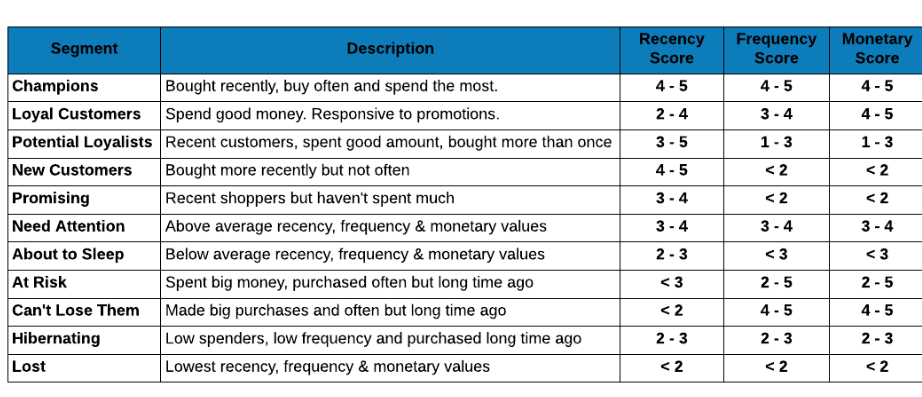

Image source: rsquareacademy.com

Segments

We will Segment our customers based on this proposed image from rsquareacademy.com

In [86]:




def calculate_rfm_scores(df):
    # Recency score (lower recency means better)
    df['R_Score'] = pd.qcut(df['recency'], 5, labels=[5, 4, 3, 2, 1])

    # Monetary score (higher monetary means better)
    df['M_Score'] = pd.qcut(df['monetary'], 5, labels=[1, 2, 3, 4, 5])

    # Frequency score (higher frequency means better)
    df['F_Score'] = pd.qcut(df['frequency'], 5, labels=[1, 2, 3, 4, 5])

    # Combine R_Score, M_Score, F_Score to get an overall RFM score
    df['RFM_Score'] = df['R_Score'].astype(int) + df['M_Score'].astype(int) + df['F_Score'].astype(int)

    return df


rmf_df = calculate_rfm_scores(rmf_df)

display(rmf_df[['CustomerID', 'recency', 'monetary', 'frequency', 'R_Score', 'M_Score', 'F_Score', 'RFM_Score']])


,CustomerID,recency,monetary,frequency,R_Score,M_Score,F_Score,RFM_Score
0,12347.0,1,4310.00,182,5,5,5,15
1,12348.0,74,1797.24,31,2,4,3,9
2,12349.0,18,1757.55,73,4,4,4,12
3,12350.0,309,334.40,17,1,2,2,5
4,12352.0,35,3466.67,95,3,5,4,12
...,...,...,...,...,...,...,...,...
4365,18280.0,277,180.60,10,1,1,1,3
4366,18281.0,180,80.82,7,1,1,1,3
4367,18282.0,7,179.50,13,5,1,1,7
4368,18283.0,3,2094.88,756,5,5,5,15


In [87]:
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champion'
    elif row['R_Score'] >= 2 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customer'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 3 and row['M_Score'] <= 3:
        return 'Potential Loyalist'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 1 and row['M_Score'] <= 1:
        return 'New Customer'
    elif (row['R_Score'] == 3 or row['R_Score'] == 4) and row['F_Score'] <= 1 and row['M_Score'] <= 1:
        return 'Promising'
    elif (row['R_Score'] == 2 or row['R_Score'] == 3) and (row['F_Score'] == 2 or row['F_Score'] == 3) and (row['M_Score'] == 2 or row['M_Score'] == 3):
        return 'Need Attention'
    elif (row['R_Score'] == 2 or row['R_Score'] == 3) and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'About to Sleep'
    elif row['R_Score'] <= 2 and row['F_Score'] > 2 and row['M_Score'] > 2:
        return 'At Risk'
    elif row['R_Score'] <= 1 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Can\'t lose them'
    elif row['R_Score'] <= 2 and row['F_Score'] == 2 and row['M_Score'] == 2:
        return 'Hibernating'
    else:
        return 'Lost'


rmf_df['segment'] = rmf_df.apply(segment_customer, axis=1)


display(rmf_df[['CustomerID', 'recency', 'monetary', 'frequency', 'R_Score', 'M_Score', 'F_Score', 'segment']])


,CustomerID,recency,monetary,frequency,R_Score,M_Score,F_Score,segment
0,12347.0,1,4310.00,182,5,5,5,Champion
1,12348.0,74,1797.24,31,2,4,3,Loyal Customer
2,12349.0,18,1757.55,73,4,4,4,Champion
3,12350.0,309,334.40,17,1,2,2,Hibernating
4,12352.0,35,3466.67,95,3,5,4,Loyal Customer
...,...,...,...,...,...,...,...,...
4365,18280.0,277,180.60,10,1,1,1,Lost
4366,18281.0,180,80.82,7,1,1,1,Lost
4367,18282.0,7,179.50,13,5,1,1,Potential Loyalist
4368,18283.0,3,2094.88,756,5,5,5,Champion


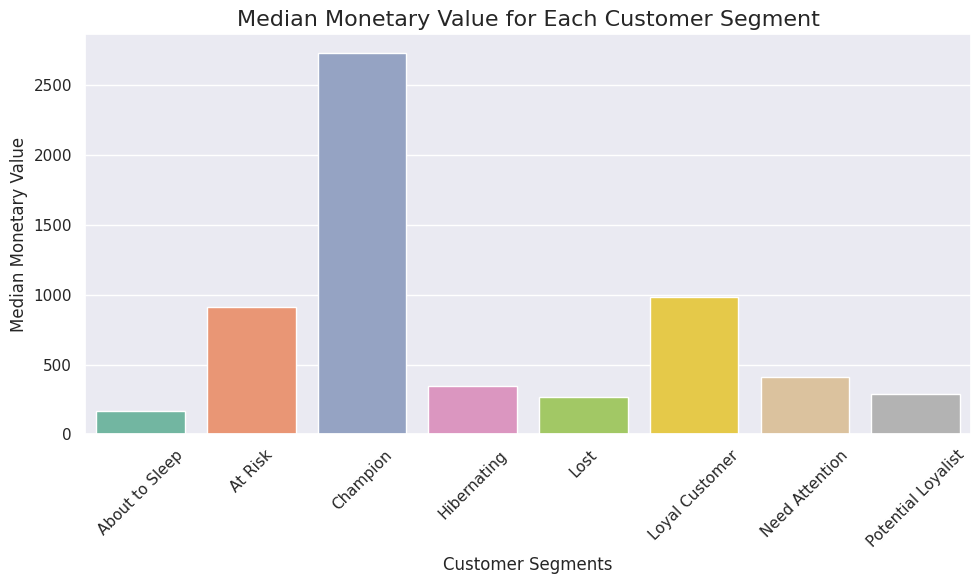

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns




median_monetary_values = rmf_df.groupby('segment')['monetary'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='monetary', data=median_monetary_values, palette='Set2')


plt.title('Median Monetary Value for Each Customer Segment', fontsize=16)
plt.xlabel('Customer Segments', fontsize=12)
plt.ylabel('Median Monetary Value', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()


We see how the median monetary value is generated mainly by our Champion Customers. At second place comes Loyal Customers, which are customers who have generated revenue for the store. Still, their recency score is low, so the store should focus on retaining these customers through marketing campaigns, promotions, and potential discounts, thus enforcing their relationship.

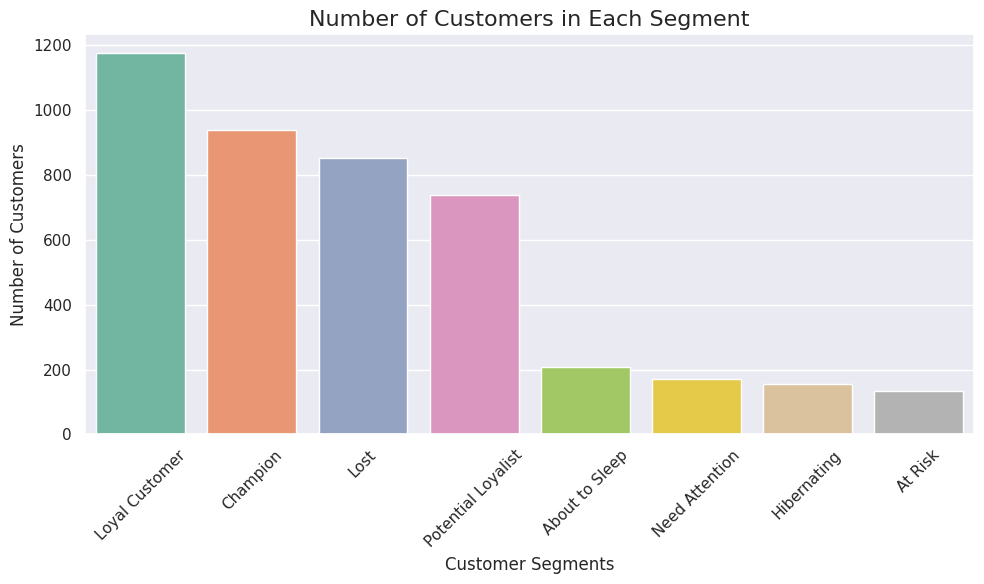

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns




segment_counts = rmf_df['segment'].value_counts()


plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Set2')


plt.title('Number of Customers in Each Segment', fontsize=16)
plt.xlabel('Customer Segments', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()


**Let's reduce the dimensions of the data and use Hierarchical clusering**

In [90]:
tsne_projection = TSNE(n_components=2,
                       perplexity=3,
                       learning_rate=1,
                       init='pca',
                       method='barnes_hut',
                       n_jobs=2,
                       n_iter=10**4,
                       random_state=0).fit_transform(scaled_data)

In [91]:
tsne_projection.shape

(4370, 2)

In [92]:
agglomerative = AgglomerativeClustering(n_clusters=5 , metric='euclidean' , linkage='ward')
agglomerative.fit(tsne_projection)
agglomerative.labels_

array([2, 1, 0, ..., 0, 4, 4])

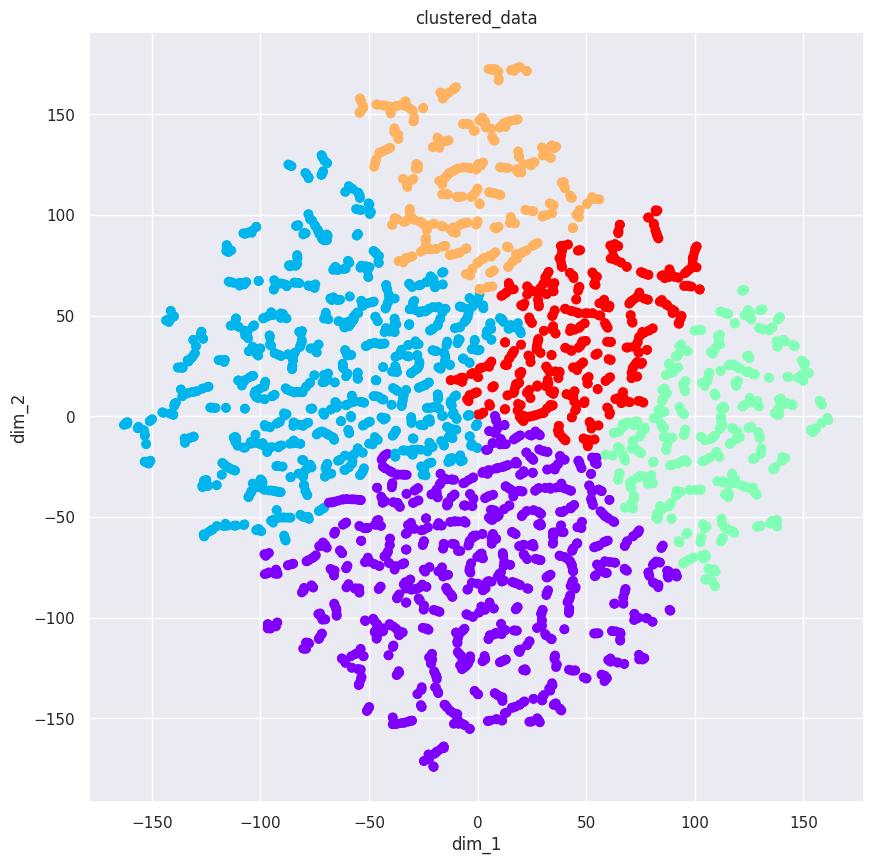

In [93]:
plt.scatter(tsne_projection[:,0],tsne_projection[:,1] , c=agglomerative.labels_ , cmap='rainbow')
plt.title('clustered_data')
plt.xlabel('dim_1')
plt.ylabel('dim_2')
plt.show()

In this analysis I explored the online retail data to try and observe important factors for the business and segment the customer base into insightful information that can be implemented for better customer relationship management.

More specifically I identified 3 important customer clusters through the k-means approach(5 clusters in total).

Consequently I implemented an RFM analysis and segmented the customers into more specific groups to drive actions. The interactive datatable above can serve as an indicative for CRM practices.

Other key differentiators For more in depth division of customers into appropriate groups, other data that could be used include:

Demographics (age, race, religion, gender, family size, ethnicity, income, education level)

Psychographic (social class, lifestyle and personality characteristics)

Geography (more specific locations)

K-means clustering algorithm & Disadvantages:

K-means clustering is a straightforward and quick technique. Furthermore, it is capable of handling massive data sets with ease. The k-means strategy, on the other hand, has some flaws. K-means clustering has the drawback of requiring us to define the number of clusters ahead of time. Another downside of K-means is that it is sensitive to outliers, and different results can be obtained if the data is reordered.

Same stands for RFM analysis. At the end, the way that a company would choose to segment its customer base would depend upon the philosophy and culture of the company. Furthermore, the unique type of product or service they provide would also play a major role on the approach that they would want to use, as well as, the categorization of their customers and where they would want to focus their efforts for better customer relationships and thus profitable future.